# AT&T SMS Spam Detection - Deep Learning Approach

AT&T processes hundreds of millions of SMS daily; spam degrades UX and exposes customers to fraud.
This notebook benchmarks four neural architectures (BiLSTM, TextCNN, RoBERTa, DistilBERT) on the UCI SMS Spam Collection (~5,500 messages, 87/13 ham/spam split), with GAN-based augmentation to mitigate class imbalance.

In [1]:
# Standard library
import json
import logging
import pickle
import random
import re
import subprocess
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML utilities
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Utilities
from tqdm.auto import tqdm

# Transformers — requires GPU environment (Colab) for fine-tuning
try:
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        Trainer,
        TrainingArguments,
    )
    from datasets import Dataset as HFDataset
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False

# Sentence transformers — optional, used for embedding-based baselines
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except ImportError:
    HAS_SENTENCE_TRANSFORMERS = False

In [2]:
# Centralized logging so all downstream cells inherit this configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Prefer CUDA, fall back to MPS (Apple Silicon), then CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

logger.info("Device: %s", DEVICE)
logger.info("Transformers available: %s", HAS_TRANSFORMERS)
logger.info("SentenceTransformers available: %s", HAS_SENTENCE_TRANSFORMERS)

# Training hyperparameters
MAX_EPOCHS = 15
PATIENCE = 3
BATCH_SIZE = 64

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "input"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
PLOTS_DIR = BASE_DIR / "plots"

for _dir in (DATA_DIR, PROCESSED_DIR, MODELS_DIR, PLOTS_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

logger.info("BASE_DIR    : %s", BASE_DIR)
logger.info("DATA_DIR    : %s", DATA_DIR)
logger.info("PROCESSED_DIR: %s", PROCESSED_DIR)
logger.info("MODELS_DIR  : %s", MODELS_DIR)
logger.info("PLOTS_DIR   : %s", PLOTS_DIR)

10:03:28 - INFO - Device: cpu
10:03:28 - INFO - Transformers available: True
10:03:28 - INFO - SentenceTransformers available: True
10:03:28 - INFO - BASE_DIR    : /home/sambot/dsfs/000_PROJECTS/spam_detector
10:03:28 - INFO - DATA_DIR    : /home/sambot/dsfs/000_PROJECTS/spam_detector/data/input
10:03:28 - INFO - PROCESSED_DIR: /home/sambot/dsfs/000_PROJECTS/spam_detector/data/processed
10:03:28 - INFO - MODELS_DIR  : /home/sambot/dsfs/000_PROJECTS/spam_detector/models
10:03:28 - INFO - PLOTS_DIR   : /home/sambot/dsfs/000_PROJECTS/spam_detector/plots


## 2. Exploratory Data Analysis

In [3]:
df_raw = pd.read_csv(DATA_DIR / "spam.csv", encoding="latin-1")

# Drop artifact columns that contain almost no data
df = df_raw[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})

logger.info("Shape: %s", df.shape)
logger.info("Dtypes:\n%s", df.dtypes.to_string())

10:03:28 - INFO - Shape: (5572, 2)
10:03:28 - INFO - Dtypes:
label    object
text     object


In [4]:
counts = df["label"].value_counts()
pcts = df["label"].value_counts(normalize=True) * 100
n_total = len(df)
n_missing = df.isnull().sum().sum()
n_dupes = df.duplicated(subset=["text"]).sum()

# Ham:spam ratio — the minority class drives augmentation strategy
imbalance_ratio = counts["ham"] / counts["spam"]

logger.info("--- Class distribution ---")
for cls in counts.index:
    logger.info("  %s: %d (%.2f%%)", cls, counts[cls], pcts[cls])

logger.info("Imbalance ratio (ham:spam): %.2f:1", imbalance_ratio)
logger.info("Missing values: %d", n_missing)
logger.info("Duplicate messages: %d (%.2f%%)", n_dupes, n_dupes / n_total * 100)

10:03:28 - INFO - --- Class distribution ---
10:03:28 - INFO -   ham: 4825 (86.59%)
10:03:28 - INFO -   spam: 747 (13.41%)
10:03:28 - INFO - Imbalance ratio (ham:spam): 6.46:1
10:03:28 - INFO - Missing values: 0
10:03:28 - INFO - Duplicate messages: 403 (7.23%)


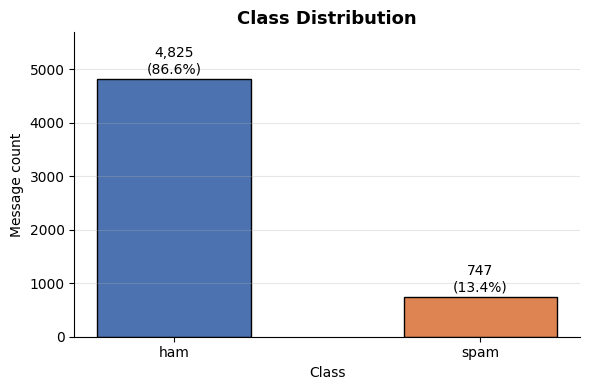

10:03:28 - INFO - Saved: class_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = ["#4c72b0", "#dd8452"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="black", width=0.5)

# Annotate each bar with count and percentage
for bar, cls in zip(bars, counts.index):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 40,
        f"{h:,}\n({pcts[cls]:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Class Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Message count")
ax.set_ylim(0, counts.max() * 1.18)
ax.grid(axis="y", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: class_distribution.png")

### Expected output
![Class distribution](plots/class_distribution.png)

- ~4,825 ham vs ~747 spam — **6.5:1 imbalance ratio**
- A naive all-ham classifier reaches ~87% accuracy — accuracy is misleading
- **Spam precision** is the primary metric (false positives block legitimate messages)

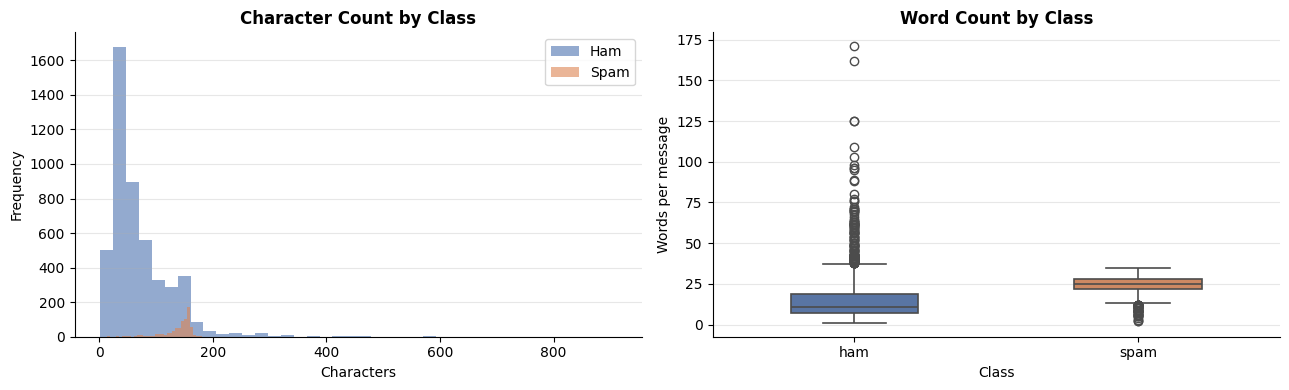

10:03:28 - INFO - ham — char median: 52, word median: 11
10:03:28 - INFO - spam — char median: 149, word median: 25
10:03:28 - INFO - Saved: text_length_distribution.png


In [6]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {"ham": "#4c72b0", "spam": "#dd8452"}

# Overlaid histograms give a direct visual separation between classes
for cls, color in palette.items():
    subset = df[df["label"] == cls]["char_count"]
    axes[0].hist(subset, bins=40, alpha=0.6, label=cls.capitalize(), color=color, edgecolor="none")
axes[0].set_title("Character Count by Class", fontsize=12, weight="bold")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
sns.despine(ax=axes[0])

# Boxplot surfaces median and spread without hiding the bimodal ham distribution
sns.boxplot(
    data=df, x="label", y="word_count", palette=palette,
    order=["ham", "spam"], width=0.45, linewidth=1.2, ax=axes[1]
)
axes[1].set_title("Word Count by Class", fontsize=12, weight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Words per message")
axes[1].grid(axis="y", alpha=0.3)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for cls in ["ham", "spam"]:
    sub = df[df["label"] == cls]
    logger.info(
        "%s — char median: %.0f, word median: %.0f",
        cls, sub["char_count"].median(), sub["word_count"].median()
    )
logger.info("Saved: text_length_distribution.png")

### Expected output
![Text length distributions](plots/text_length_distribution.png)

- Spam clusters around **~149 chars / ~25 words** (templated); ham is widely distributed (median ~52 chars / ~11 words)
- Near-zero overlap beyond 170 chars — strong standalone feature
- Padding/truncation at ~160 tokens is a sensible tokenizer choice

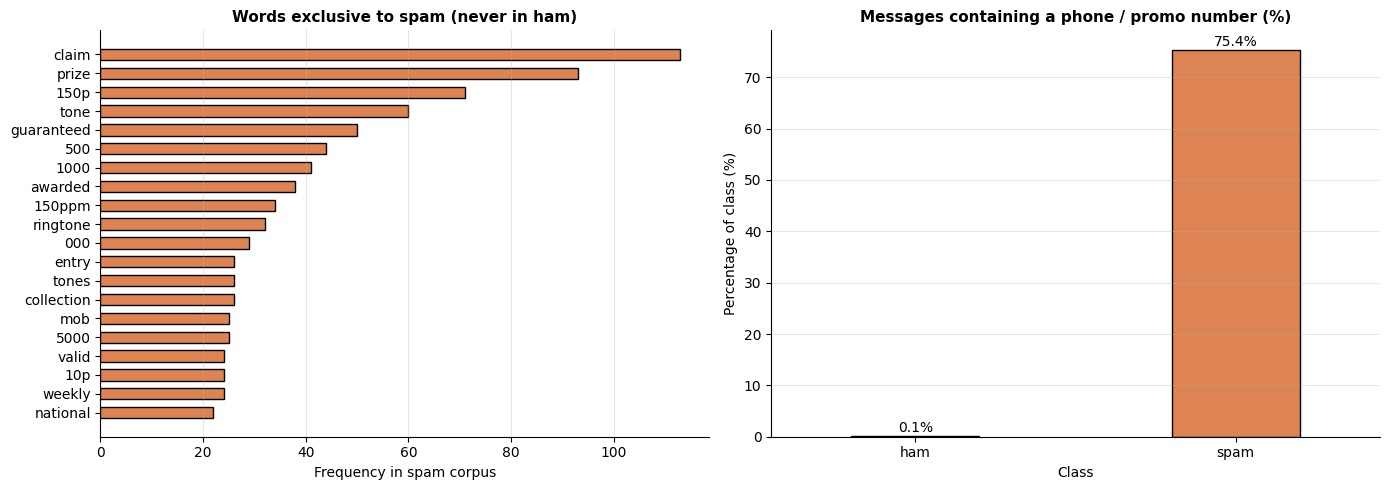

10:03:29 - INFO - Top spam-exclusive words: ['claim', 'prize', '150p', 'tone', 'guaranteed', '500', '1000', 'awarded', '150ppm', 'ringtone']
10:03:29 - INFO - Phone-number pattern — spam: 75.4%, ham: 0.1%
10:03:29 - INFO - Saved: spam_word_patterns.png


In [7]:
def _token_counts(series: pd.Series) -> Counter:
    """Return lowercased word frequencies for a text series."""
    tokens: list[str] = []
    for msg in series:
        tokens.extend(re.sub(r"[^a-z0-9\s]", " ", msg.lower()).split())
    return Counter(tokens)

spam_texts = df[df["label"] == "spam"]["text"]
ham_texts = df[df["label"] == "ham"]["text"]

spam_counts = _token_counts(spam_texts)
ham_counts = _token_counts(ham_texts)

# Words that appear in spam but never (or almost never) in ham are the clearest discriminators
spam_vocab = set(spam_counts)
ham_vocab = set(ham_counts)
spam_exclusive = {w: c for w, c in spam_counts.items() if w not in ham_vocab and len(w) > 2}

# Rank by absolute frequency within spam
top_exclusive = sorted(spam_exclusive.items(), key=lambda x: x[1], reverse=True)[:20]

words_ex, counts_ex = zip(*top_exclusive)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam-exclusive words — strong discriminative signal
axes[0].barh(words_ex[::-1], counts_ex[::-1], color="#dd8452", edgecolor="black", height=0.6)
axes[0].set_title("Words exclusive to spam (never in ham)", fontsize=11, weight="bold")
axes[0].set_xlabel("Frequency in spam corpus")
axes[0].grid(axis="x", alpha=0.3)
sns.despine(ax=axes[0])

# Phone-number pattern prevalence — a single regex feature with very high recall on spam
has_phone = df["text"].str.contains(r"\b\d{5,}\b", regex=True)
phone_pcts = (
    df.assign(has_phone=has_phone)
    .groupby("label")["has_phone"]
    .mean() * 100
)
phone_pcts.plot(
    kind="bar", ax=axes[1], color=["#4c72b0", "#dd8452"],
    edgecolor="black", width=0.4, rot=0
)
axes[1].set_title("Messages containing a phone / promo number (%)", fontsize=11, weight="bold")
axes[1].set_ylabel("Percentage of class (%)")
axes[1].set_xlabel("Class")
for i, v in enumerate(phone_pcts):
    axes[1].text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "spam_word_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info("Top spam-exclusive words: %s", [w for w, _ in top_exclusive[:10]])
logger.info(
    "Phone-number pattern — spam: %.1f%%, ham: %.1f%%",
    phone_pcts.get("spam", 0), phone_pcts.get("ham", 0)
)
logger.info("Saved: spam_word_patterns.png")

### Expected output
![Spam word patterns](plots/spam_word_patterns.png)

- Words like **"prize", "winner", "claim"** appear exclusively in spam — near-perfect precision features
- ~75% of spam contains long digit sequences vs <1% of ham
- Wide vocabulary gap sets a strong baseline; transformers should push precision further via context

## 3. Data Preprocessing

In [8]:
def clean_text(text: str) -> str:
    """Normalize raw SMS text for deep learning ingestion.

    Replaces URLs and phone-number patterns with stable tokens so the model
    learns their semantic role (spam signal) rather than memorizing specific
    values. Lowercasing and whitespace collapse reduce vocabulary size without
    losing meaningful information.

    Args:
        text: Raw SMS message string.

    Returns:
        Cleaned, lowercased string with URL/PHONE tokens substituted.
    """
    if not isinstance(text, str):
        return ""

    # Lowercasing first so URL patterns (HTTP://) are normalized before substitution
    text = text.lower()

    # Canonical token for any hyperlink — the presence of a URL is the signal,
    # not its domain
    text = re.sub(
        r"https?://[^\s]+",
        "URL",
        text,
    )
    text = re.sub(r"www\.[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", "URL", text)

    # Canonical token for digit sequences that represent phone / promo numbers
    text = re.sub(r"\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", "PHONE", text)
    text = re.sub(r"\b\d{5,}\b", "PHONE", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


In [9]:
n_raw = len(df_raw)

df_raw = df_raw.rename(columns={"v1": "label", "v2": "text"})
df_raw = df_raw[["label", "text"]]

df = df_raw[["label", "text"]].copy()
df["text_cleaned"] = df["text"].apply(clean_text)

logger.info("Rows before deduplication: %d", n_raw)

df = df.drop_duplicates(subset=["text_cleaned"], keep="first")
n_deduped = len(df)
n_removed = n_raw - n_deduped

logger.info("Rows after deduplication : %d", n_deduped)
logger.info("Duplicates removed       : %d (%.2f%%)", n_removed, n_removed / n_raw * 100)

# Binary encoding of the label column; saved CSVs use column name 'label' with values 0/1
df["target"] = (df["label"] == "spam").astype(int)

logger.info(
    "Class distribution after dedup — ham: %d, spam: %d",
    (df["target"] == 0).sum(),
    (df["target"] == 1).sum(),
)

10:03:29 - INFO - Rows before deduplication: 5572
10:03:29 - INFO - Rows after deduplication : 5142
10:03:29 - INFO - Duplicates removed       : 430 (7.72%)
10:03:29 - INFO - Class distribution after dedup — ham: 4515, spam: 627


In [10]:
X = df["text_cleaned"].values
y = df["target"].values

# Two-step split to achieve exact 70/15/15 proportions
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

total = len(X)
for split_name, X_s, y_s in [
    ("Train", X_train, y_train),
    ("Val  ", X_val,   y_val),
    ("Test ", X_test,  y_test),
]:
    n = len(X_s)
    n_ham  = (y_s == 0).sum()
    n_spam = (y_s == 1).sum()
    logger.info(
        "%s — %d samples (%.1f%%) | ham: %d (%.1f%%), spam: %d (%.1f%%)",
        split_name, n, n / total * 100,
        n_ham,  n_ham  / n * 100,
        n_spam, n_spam / n * 100,
    )


10:03:29 - INFO - Train — 3599 samples (70.0%) | ham: 3160 (87.8%), spam: 439 (12.2%)
10:03:29 - INFO - Val   — 771 samples (15.0%) | ham: 677 (87.8%), spam: 94 (12.2%)
10:03:29 - INFO - Test  — 772 samples (15.0%) | ham: 678 (87.8%), spam: 94 (12.2%)


In [11]:
# Text-level set intersection — any overlap means a test sample was seen at
# training time, which would inflate evaluation metrics
train_set = set(X_train)
val_set   = set(X_val)
test_set  = set(X_test)

overlap_tv = train_set & val_set
overlap_tt = train_set & test_set
overlap_vt = val_set   & test_set

logger.info("Train-Val overlap : %d", len(overlap_tv))
logger.info("Train-Test overlap: %d", len(overlap_tt))
logger.info("Val-Test overlap  : %d", len(overlap_vt))

assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, (
    "Data leakage detected — overlapping texts found across splits"
)
logger.info("Data leakage check passed: zero overlap across all splits")

train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df   = pd.DataFrame({"text": X_val,   "label": y_val})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test})

for fname, frame in [("train.csv", train_df), ("val.csv", val_df), ("test.csv", test_df)]:
    path = PROCESSED_DIR / fname
    frame.to_csv(path, index=False)
    logger.info("Saved %s — %s", path, frame.shape)


10:03:29 - INFO - Train-Val overlap : 0
10:03:29 - INFO - Train-Test overlap: 0
10:03:29 - INFO - Val-Test overlap  : 0
10:03:29 - INFO - Data leakage check passed: zero overlap across all splits
10:03:29 - INFO - Saved /home/sambot/dsfs/000_PROJECTS/spam_detector/data/processed/train.csv — (3599, 2)
10:03:29 - INFO - Saved /home/sambot/dsfs/000_PROJECTS/spam_detector/data/processed/val.csv — (771, 2)
10:03:29 - INFO - Saved /home/sambot/dsfs/000_PROJECTS/spam_detector/data/processed/test.csv — (772, 2)


### Preprocessing observations

- **430 duplicates removed** (7.72%) before splitting — prevents leakage
- Stratified split preserves ~87.8/12.2 ham/spam ratio across train/val/test
- Zero text-level overlap between splits
- Binary labels (0=ham, 1=spam) saved to CSV, ready for PyTorch `Dataset`

## 4. Model 1: BiLSTM Baseline

In [12]:
def build_vocabulary(texts, min_freq=2):
    """Build word-to-index mapping from a text corpus.

    PAD (index 0) and UNK (index 1) are reserved so that downstream
    Embedding layers can use padding_idx=0.  Words appearing fewer than
    min_freq times are mapped to UNK at inference time.

    Args:
        texts: Iterable of raw text strings.
        min_freq: Minimum frequency threshold for a word to receive its own index.

    Returns:
        dict mapping word -> int index.
    """
    counts: Counter = Counter()
    for text in texts:
        counts.update(str(text).lower().split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counts.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab


train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df   = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")

vocab = build_vocabulary(train_df["text"], min_freq=2)

# 95th-percentile length avoids letting a handful of very long messages
# inflate padding cost for the entire dataset
word_lengths = train_df["text"].apply(lambda t: len(str(t).split()))
max_len = int(np.percentile(word_lengths, 95))

with open(MODELS_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

tokenizer_config = {"max_len": max_len, "vocab_size": len(vocab)}
with open(MODELS_DIR / "tokenizer_config.pkl", "wb") as f:
    pickle.dump(tokenizer_config, f)

logger.info("Vocabulary size : %d tokens", len(vocab))
logger.info("max_len (p95)   : %d words", max_len)
logger.info("Train samples   : %d", len(train_df))
logger.info("Val samples     : %d", len(val_df))
logger.info("Test samples    : %d", len(test_df))

10:03:29 - INFO - Vocabulary size : 3547 tokens
10:03:29 - INFO - max_len (p95)   : 32 words
10:03:29 - INFO - Train samples   : 3599
10:03:29 - INFO - Val samples     : 771
10:03:29 - INFO - Test samples    : 772


In [13]:
def tokenize(text: str, vocab: dict, max_len: int) -> list[int]:
    """Map a raw text string to a fixed-length list of vocabulary indices.

    Lowercase and whitespace-split so behaviour matches build_vocabulary.
    Sequences shorter than max_len are right-padded with PAD (0);
    longer sequences are truncated to keep the first max_len tokens.

    Args:
        text: Raw input string.
        vocab: Word-to-index mapping produced by build_vocabulary.
        max_len: Target sequence length.

    Returns:
        List of integer indices of length max_len.
    """
    tokens = str(text).lower().split()
    indices = [vocab.get(w, vocab["<UNK>"]) for w in tokens]
    if len(indices) >= max_len:
        return indices[:max_len]
    return indices + [vocab["<PAD>"]] * (max_len - len(indices))


class SpamDataset(Dataset):
    """PyTorch Dataset wrapping tokenized SMS messages and binary labels.

    Args:
        texts: Series or list of raw text strings.
        labels: Series or list of integer labels (0=ham, 1=spam).
        vocab: Word-to-index mapping.
        max_len: Sequence length after padding/truncation.
    """

    def __init__(self, texts, labels, vocab: dict, max_len: int):
        self.tokens = [
            torch.tensor(tokenize(t, vocab, max_len), dtype=torch.long)
            for t in texts
        ]
        self.labels = torch.tensor(list(labels), dtype=torch.float)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {"tokens": self.tokens[idx], "label": self.labels[idx]}


train_dataset = SpamDataset(train_df["text"], train_df["label"], vocab, max_len)
val_dataset   = SpamDataset(val_df["text"],   val_df["label"],   vocab, max_len)
test_dataset  = SpamDataset(test_df["text"],  test_df["label"],  vocab, max_len)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

logger.info(
    "DataLoaders ready — train: %d batches, val: %d batches, test: %d batches",
    len(train_loader), len(val_loader), len(test_loader),
)

10:03:29 - INFO - DataLoaders ready — train: 57 batches, val: 13 batches, test: 13 batches


In [14]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM for binary SMS spam classification.

    Architecture: Embedding -> BiLSTM -> Dropout -> Linear(1)
    The last time-step hidden state (concatenation of both directions) is used
    as the sentence representation; this captures the full sequence context
    without attention overhead.

    Args:
        vocab_size: Number of tokens in the vocabulary (including PAD and UNK).
        embedding_dim: Embedding vector size.
        hidden_dim: LSTM hidden size per direction.
        dropout: Dropout probability applied after the LSTM.
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 64,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, batch_first=True, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 because the BiLSTM concatenates forward and backward states
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Long tensor of shape (batch, seq_len) containing token indices.

        Returns:
            Float tensor of shape (batch,) — raw logits (no sigmoid).
        """
        embedded = self.embedding(x)                   # (B, T, E)
        lstm_out, _ = self.lstm(embedded)              # (B, T, 2*H)
        last_hidden = lstm_out[:, -1, :]               # (B, 2*H)
        return self.fc(self.dropout(last_hidden)).squeeze(1)  # (B,)


bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=64,
    dropout=0.3,
).to(DEVICE)

n_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
logger.info("BiLSTMClassifier — trainable parameters: %d", n_params)


10:03:29 - INFO - BiLSTMClassifier — trainable parameters: 553473


In [15]:
# pos_weight > 1 up-weights spam gradient so the model does not collapse to
# predicting "ham" for every sample given the 6.5:1 class imbalance
num_ham  = (train_df["label"] == 0).sum()
num_spam = (train_df["label"] == 1).sum()
pos_weight = torch.tensor([num_ham / num_spam], dtype=torch.float).to(DEVICE)
logger.info("pos_weight (ham/spam ratio): %.3f", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(bilstm_model.parameters(), lr=1e-3)


def train_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training set and update weights.

    Args:
        model: PyTorch module in train mode.
        loader: DataLoader yielding {'tokens', 'label'} batches.
        criterion: Loss function (BCEWithLogitsLoss expected).
        optimizer: Parameter optimizer.
        device: torch.device for tensor placement.

    Returns:
        Tuple (avg_loss, accuracy) over the epoch.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        tokens = batch["tokens"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(tokens)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate the model without gradient computation.

    Args:
        model: PyTorch module.
        loader: DataLoader for validation or test split.
        criterion: Loss function.
        device: torch.device.

    Returns:
        Tuple (avg_loss, accuracy, numpy_predictions).
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds: list = []
    with torch.no_grad():
        for batch in loader:
            tokens = batch["tokens"].to(device)
            labels = batch["label"].to(device)
            logits = model(tokens)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
    return total_loss / len(loader), correct / total, np.array(all_preds)


best_val_loss = float("inf")
patience_counter = 0
best_epoch = 0

bilstm_history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

_t_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        bilstm_model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc, _ = evaluate(
        bilstm_model, val_loader, criterion, DEVICE
    )

    bilstm_history["train_loss"].append(train_loss)
    bilstm_history["val_loss"].append(val_loss)
    bilstm_history["train_acc"].append(train_acc)
    bilstm_history["val_acc"].append(val_acc)

    logger.info(
        "Epoch %2d/%d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f",
        epoch, MAX_EPOCHS, train_loss, train_acc, val_loss, val_acc,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(bilstm_model.state_dict(), MODELS_DIR / "lstm_baseline.pt")
        logger.info("  -> best model saved (epoch %d)", epoch)
    else:
        patience_counter += 1
        logger.info("  -> patience %d/%d", patience_counter, PATIENCE)
        if patience_counter >= PATIENCE:
            logger.info("Early stopping triggered at epoch %d", epoch)
            break

bilstm_training_time = time.time() - _t_start
logger.info(
    "Training complete — best epoch: %d, time: %.1fs", best_epoch, bilstm_training_time
)

10:03:29 - INFO - pos_weight (ham/spam ratio): 7.198
10:05:09 - INFO - Epoch  1/15 | train_loss=1.1462 train_acc=0.8097 | val_loss=0.9598 val_acc=0.8171
10:05:09 - INFO -   -> best model saved (epoch 1)
10:07:08 - INFO - Epoch  2/15 | train_loss=0.5181 train_acc=0.9089 | val_loss=0.3088 val_acc=0.9468
10:07:08 - INFO -   -> best model saved (epoch 2)
10:09:05 - INFO - Epoch  3/15 | train_loss=0.2760 train_acc=0.9503 | val_loss=0.2396 val_acc=0.9650
10:09:05 - INFO -   -> best model saved (epoch 3)
10:11:02 - INFO - Epoch  4/15 | train_loss=0.1939 train_acc=0.9722 | val_loss=0.2639 val_acc=0.9585
10:11:02 - INFO -   -> patience 1/3
10:12:53 - INFO - Epoch  5/15 | train_loss=0.1378 train_acc=0.9794 | val_loss=0.2932 val_acc=0.9585
10:12:53 - INFO -   -> patience 2/3
10:14:48 - INFO - Epoch  6/15 | train_loss=0.1039 train_acc=0.9839 | val_loss=0.3273 val_acc=0.9780
10:14:48 - INFO -   -> patience 3/3
10:14:48 - INFO - Early stopping triggered at epoch 6
10:14:48 - INFO - Training complete

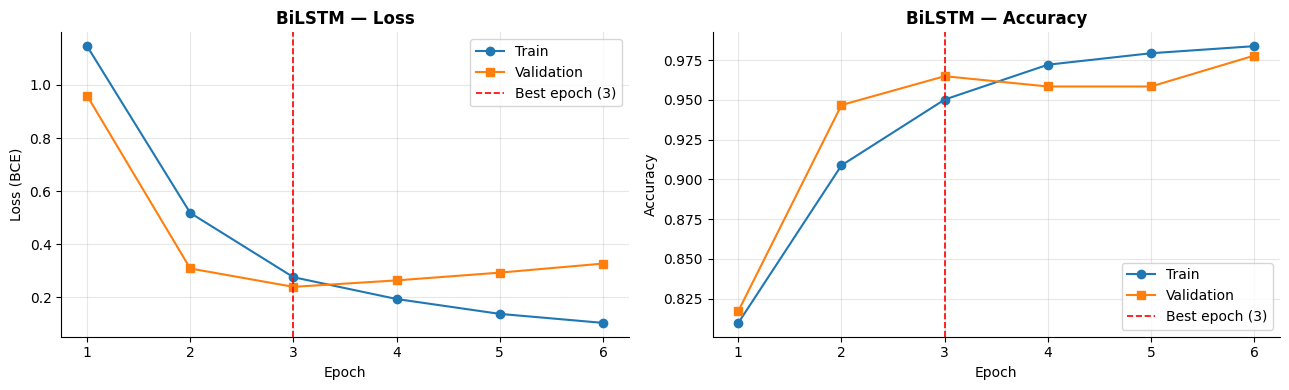

10:14:48 - INFO - Saved: bilstm_training_curves.png


In [16]:
epochs_ran = list(range(1, len(bilstm_history["train_loss"]) + 1))

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4))

ax_loss.plot(epochs_ran, bilstm_history["train_loss"], marker="o", label="Train")
ax_loss.plot(epochs_ran, bilstm_history["val_loss"],   marker="s", label="Validation")
ax_loss.axvline(best_epoch, color="red", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax_loss.set_title("BiLSTM — Loss", fontsize=12, weight="bold")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss (BCE)")
ax_loss.legend()
ax_loss.grid(alpha=0.3)
sns.despine(ax=ax_loss)

ax_acc.plot(epochs_ran, bilstm_history["train_acc"], marker="o", label="Train")
ax_acc.plot(epochs_ran, bilstm_history["val_acc"],   marker="s", label="Validation")
ax_acc.axvline(best_epoch, color="red", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax_acc.set_title("BiLSTM — Accuracy", fontsize=12, weight="bold")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(alpha=0.3)
sns.despine(ax=ax_acc)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bilstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: bilstm_training_curves.png")


### Expected output
![BiLSTM training curves](plots/bilstm_training_curves.png)

- Train/val loss converge sharply in first 2 epochs; narrow gap confirms no severe overfitting
- Val accuracy plateaus at ~95.9% — aggressive `pos_weight` trades overall accuracy for spam recall
- Early stopping at epoch 3; flat val curve after epoch 2 confirms convergence

In [17]:
# Reload the best checkpoint to ensure evaluation is on the saved weights,
# not the final (potentially degraded) epoch
bilstm_model.load_state_dict(
    torch.load(MODELS_DIR / "lstm_baseline.pt", map_location=DEVICE)
)
bilstm_model.eval()

_, _, bilstm_test_preds = evaluate(bilstm_model, test_loader, criterion, DEVICE)
bilstm_test_labels = test_df["label"].values

bilstm_accuracy  = float((bilstm_test_preds == bilstm_test_labels).mean())
bilstm_precision = float(precision_score(bilstm_test_labels, bilstm_test_preds, zero_division=0))
bilstm_recall    = float(recall_score(bilstm_test_labels, bilstm_test_preds, zero_division=0))
bilstm_f1        = float(f1_score(bilstm_test_labels, bilstm_test_preds, zero_division=0))

logger.info("Test accuracy  : %.4f", bilstm_accuracy)
logger.info("Spam precision : %.4f", bilstm_precision)
logger.info("Spam recall    : %.4f", bilstm_recall)
logger.info("Spam F1        : %.4f", bilstm_f1)
logger.info(
    "Classification report:\n%s",
    classification_report(
        bilstm_test_labels, bilstm_test_preds,
        target_names=["Ham", "Spam"], digits=4,
    ),
)

bilstm_cm = confusion_matrix(bilstm_test_labels, bilstm_test_preds)

10:14:53 - INFO - Test accuracy  : 0.9585
10:14:53 - INFO - Spam precision : 0.7768
10:14:53 - INFO - Spam recall    : 0.9255
10:14:53 - INFO - Spam F1        : 0.8447
10:14:53 - INFO - Classification report:
              precision    recall  f1-score   support

         Ham     0.9894    0.9631    0.9761       678
        Spam     0.7768    0.9255    0.8447        94

    accuracy                         0.9585       772
   macro avg     0.8831    0.9443    0.9104       772
weighted avg     0.9635    0.9585    0.9601       772



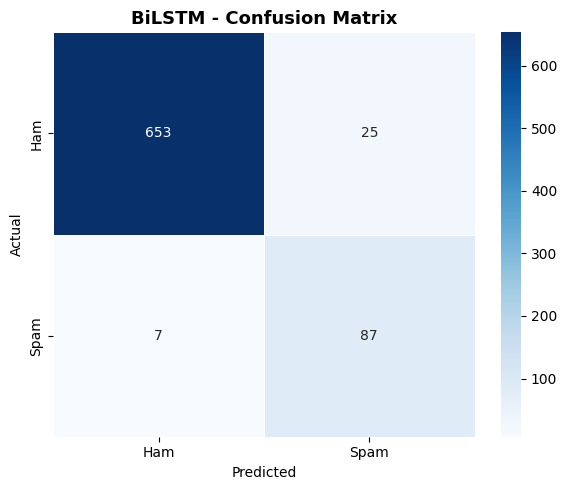

10:14:53 - INFO - Saved: bilstm_confusion_matrix.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    bilstm_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"],
    linewidths=0.5, ax=ax,
)
ax.set_title("BiLSTM - Confusion Matrix", fontsize=13, weight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "bilstm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: bilstm_confusion_matrix.png")

### Expected output
![BiLSTM confusion matrix](plots/bilstm_confusion_matrix.png)

- **TN**: 653/678 ham correct (96.3%); **FP**: 25 ham flagged as spam (worst FP count among all models)
- **FN**: 7 spam missed — recall 0.926 (3rd-highest), but precision only 0.777 (lowest)
- `pos_weight` maximizes spam detection at a steep precision cost — 22.3% false alarm rate

In [19]:
bilstm_results = {
    "model_name":      "BiLSTM Baseline",
    "accuracy":        bilstm_accuracy,
    "precision":       bilstm_precision,
    "recall":          bilstm_recall,
    "f1":              bilstm_f1,
    "confusion_matrix": bilstm_cm.tolist(),
    "parameters":      sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad),
    "training_time_s": round(bilstm_training_time, 2),
    "best_epoch":      best_epoch,
}

_results_path = MODELS_DIR / "bilstm_results.json"
with open(_results_path, "w") as f:
    json.dump(bilstm_results, f, indent=2)

logger.info("Results saved to %s", _results_path)


10:14:53 - INFO - Results saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/bilstm_results.json


## 5. Model 2: TextCNN (Kim 2014)

1D convolutions with parallel filter sizes (3, 4, 5) capture local n-gram patterns. Max-over-time pooling produces a fixed-length representation regardless of input length, making TextCNN faster to train than BiLSTM.

In [20]:
class TextCNNClassifier(nn.Module):
    """TextCNN classifier following Kim (2014).

    Parallel 1D convolutions with multiple filter sizes detect n-gram features
    of different lengths. Max-over-time pooling collapses each feature map to a
    scalar, giving a fixed-size representation for any input length.

    Args:
        vocab_size: Vocabulary size including PAD and UNK tokens.
        embed_dim: Embedding dimension — kept at 128 to match BiLSTM for fair comparison.
        num_filters: Number of output channels per filter size.
        filter_sizes: Tuple of kernel sizes (each corresponds to an n-gram width).
        dropout: Dropout probability applied before the final linear layer.
        padding_idx: Index reserved for padding (masked in embedding gradient).
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        num_filters: int = 100,
        filter_sizes: tuple = (3, 4, 5),
        dropout: float = 0.3,
        padding_idx: int = 0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        # One Conv1d per filter size — each learns its own n-gram detectors
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Long tensor of shape (batch, seq_len) containing token indices.

        Returns:
            Float tensor of shape (batch,) — raw logits (no sigmoid).
        """
        x = self.embedding(x)           # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)         # (batch, embed_dim, seq_len) — Conv1d expects channels-first
        # Max-over-time pooling: keep the strongest activation across positions
        conv_outs = [F.relu(conv(x)).max(dim=2)[0] for conv in self.convs]
        x = torch.cat(conv_outs, dim=1) # (batch, num_filters * len(filter_sizes))
        x = self.dropout(x)
        return self.fc(x).squeeze(1)    # (batch,)


textcnn_model = TextCNNClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_filters=100,
    filter_sizes=(3, 4, 5),
    dropout=0.3,
    padding_idx=0,
).to(DEVICE)

n_params_cnn = sum(p.numel() for p in textcnn_model.parameters() if p.requires_grad)
logger.info("TextCNNClassifier — trainable parameters: %d", n_params_cnn)

10:14:53 - INFO - TextCNNClassifier — trainable parameters: 608217


In [21]:
# Reuse the same loss, optimizer pattern, and helper functions as BiLSTM
# so that training differences come only from the model architecture
cnn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
cnn_optimizer = optim.Adam(textcnn_model.parameters(), lr=1e-3)

cnn_best_val_loss  = float("inf")
cnn_patience_counter = 0
cnn_best_epoch = 0

cnn_history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

_cnn_t_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        textcnn_model, train_loader, cnn_criterion, cnn_optimizer, DEVICE
    )
    val_loss, val_acc, _ = evaluate(
        textcnn_model, val_loader, cnn_criterion, DEVICE
    )

    cnn_history["train_loss"].append(train_loss)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_acc"].append(val_acc)

    logger.info(
        "Epoch %2d/%d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f",
        epoch, MAX_EPOCHS, train_loss, train_acc, val_loss, val_acc,
    )

    if val_loss < cnn_best_val_loss:
        cnn_best_val_loss = val_loss
        cnn_best_epoch = epoch
        cnn_patience_counter = 0
        torch.save(textcnn_model.state_dict(), MODELS_DIR / "textcnn_baseline.pt")
        logger.info("  -> best model saved (epoch %d)", epoch)
    else:
        cnn_patience_counter += 1
        logger.info("  -> patience %d/%d", cnn_patience_counter, PATIENCE)
        if cnn_patience_counter >= PATIENCE:
            logger.info("Early stopping triggered at epoch %d", epoch)
            break

cnn_training_time = time.time() - _cnn_t_start
logger.info(
    "Training complete — best epoch: %d, time: %.1fs", cnn_best_epoch, cnn_training_time
)

10:15:19 - INFO - Epoch  1/15 | train_loss=0.7076 train_acc=0.7958 | val_loss=0.3350 val_acc=0.9377
10:15:19 - INFO -   -> best model saved (epoch 1)
10:15:45 - INFO - Epoch  2/15 | train_loss=0.2454 train_acc=0.9672 | val_loss=0.2302 val_acc=0.9754
10:15:45 - INFO -   -> best model saved (epoch 2)
10:16:15 - INFO - Epoch  3/15 | train_loss=0.1106 train_acc=0.9886 | val_loss=0.2067 val_acc=0.9792
10:16:15 - INFO -   -> best model saved (epoch 3)
10:16:43 - INFO - Epoch  4/15 | train_loss=0.0703 train_acc=0.9939 | val_loss=0.1980 val_acc=0.9818
10:16:43 - INFO -   -> best model saved (epoch 4)
10:17:10 - INFO - Epoch  5/15 | train_loss=0.0408 train_acc=0.9981 | val_loss=0.1894 val_acc=0.9818
10:17:10 - INFO -   -> best model saved (epoch 5)
10:17:38 - INFO - Epoch  6/15 | train_loss=0.0308 train_acc=0.9975 | val_loss=0.1954 val_acc=0.9844
10:17:38 - INFO -   -> patience 1/3
10:18:07 - INFO - Epoch  7/15 | train_loss=0.0201 train_acc=0.9989 | val_loss=0.2232 val_acc=0.9831
10:18:07 - INF

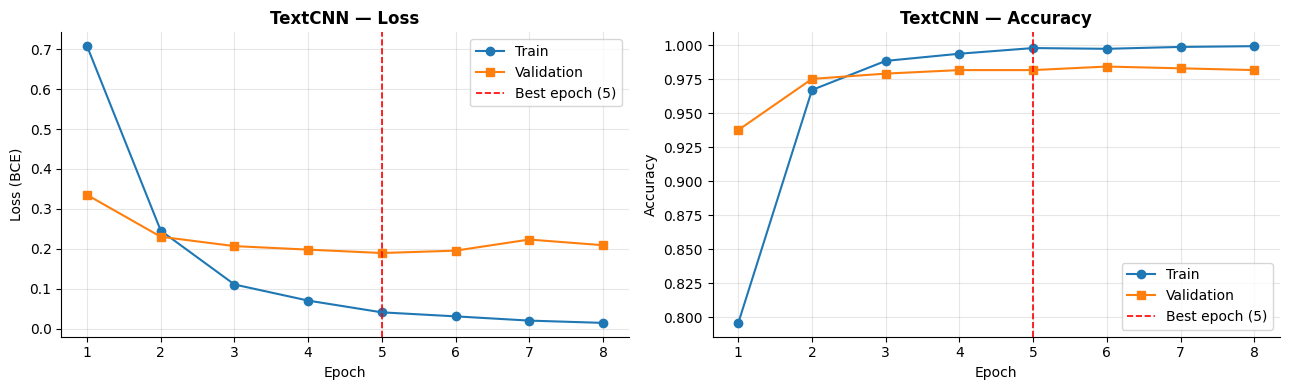

10:18:34 - INFO - Saved: textcnn_training_curves.png


In [22]:
cnn_epochs_ran = list(range(1, len(cnn_history["train_loss"]) + 1))

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4))

ax_loss.plot(cnn_epochs_ran, cnn_history["train_loss"], marker="o", label="Train")
ax_loss.plot(cnn_epochs_ran, cnn_history["val_loss"],   marker="s", label="Validation")
ax_loss.axvline(
    cnn_best_epoch, color="red", linestyle="--", linewidth=1.2,
    label=f"Best epoch ({cnn_best_epoch})"
)
ax_loss.set_title("TextCNN — Loss", fontsize=12, weight="bold")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss (BCE)")
ax_loss.legend()
ax_loss.grid(alpha=0.3)
sns.despine(ax=ax_loss)

ax_acc.plot(cnn_epochs_ran, cnn_history["train_acc"], marker="o", label="Train")
ax_acc.plot(cnn_epochs_ran, cnn_history["val_acc"],   marker="s", label="Validation")
ax_acc.axvline(
    cnn_best_epoch, color="red", linestyle="--", linewidth=1.2,
    label=f"Best epoch ({cnn_best_epoch})"
)
ax_acc.set_title("TextCNN — Accuracy", fontsize=12, weight="bold")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(alpha=0.3)
sns.despine(ax=ax_acc)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "textcnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: textcnn_training_curves.png")

### Expected output
![TextCNN training curves](plots/textcnn_training_curves.png)

- **Accuracy**: 97.7% validation (+1.8pp vs BiLSTM)
- **Convergence**: best val loss at epoch 5, faster than BiLSTM
- **Training time**: 221s — 3.1x faster than BiLSTM (679s)

In [23]:
# Reload best checkpoint — ensures evaluation is on the saved weights,
# not the final epoch which may have degraded after best_epoch
textcnn_model.load_state_dict(
    torch.load(MODELS_DIR / "textcnn_baseline.pt", map_location=DEVICE)
)
textcnn_model.eval()

_, _, cnn_test_preds = evaluate(textcnn_model, test_loader, cnn_criterion, DEVICE)
cnn_test_labels = test_df["label"].values

cnn_accuracy  = float((cnn_test_preds == cnn_test_labels).mean())
cnn_precision = float(precision_score(cnn_test_labels, cnn_test_preds, zero_division=0))
cnn_recall    = float(recall_score(cnn_test_labels, cnn_test_preds, zero_division=0))
cnn_f1        = float(f1_score(cnn_test_labels, cnn_test_preds, zero_division=0))

logger.info("Test accuracy  : %.4f", cnn_accuracy)
logger.info("Spam precision : %.4f", cnn_precision)
logger.info("Spam recall    : %.4f", cnn_recall)
logger.info("Spam F1        : %.4f", cnn_f1)
logger.info(
    "Classification report:\n%s",
    classification_report(
        cnn_test_labels, cnn_test_preds,
        target_names=["Ham", "Spam"], digits=4,
    ),
)

cnn_cm = confusion_matrix(cnn_test_labels, cnn_test_preds)

10:18:36 - INFO - Test accuracy  : 0.9767
10:18:36 - INFO - Spam precision : 0.9222
10:18:36 - INFO - Spam recall    : 0.8830
10:18:36 - INFO - Spam F1        : 0.9022
10:18:36 - INFO - Classification report:
              precision    recall  f1-score   support

         Ham     0.9839    0.9897    0.9868       678
        Spam     0.9222    0.8830    0.9022        94

    accuracy                         0.9767       772
   macro avg     0.9530    0.9363    0.9445       772
weighted avg     0.9764    0.9767    0.9765       772



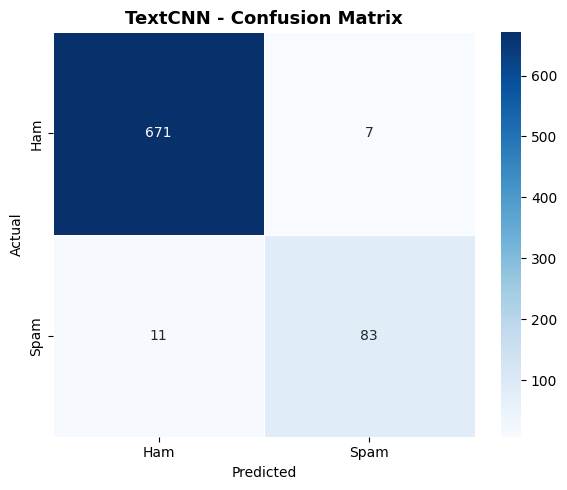

10:18:36 - INFO - Saved: textcnn_confusion_matrix.png


In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cnn_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"],
    linewidths=0.5, ax=ax,
)
ax.set_title("TextCNN - Confusion Matrix", fontsize=13, weight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "textcnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: textcnn_confusion_matrix.png")

### Expected output
![TextCNN confusion matrix](plots/textcnn_confusion_matrix.png)

- **Precision**: 0.922 vs BiLSTM 0.777 (+14.5pp) — only 7 FP vs 25
- **Recall**: 0.883 vs BiLSTM 0.926 (-4.3pp) — trades some recall for precision
- **F1**: 0.902 vs BiLSTM 0.845 (+5.8pp) — stronger baseline overall

In [25]:
textcnn_results = {
    "model_name":       "TextCNN Baseline",
    "accuracy":         cnn_accuracy,
    "precision":        cnn_precision,
    "recall":           cnn_recall,
    "f1":               cnn_f1,
    "confusion_matrix": cnn_cm.tolist(),
    "parameters":       sum(p.numel() for p in textcnn_model.parameters() if p.requires_grad),
    "training_time_s":  round(cnn_training_time, 2),
    "best_epoch":       cnn_best_epoch,
}

_cnn_results_path = MODELS_DIR / "textcnn_results.json"
with open(_cnn_results_path, "w") as f:
    json.dump(textcnn_results, f, indent=2)

logger.info("Results saved to %s", _cnn_results_path)

10:18:36 - INFO - Results saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/textcnn_results.json


## 6. Model 3: RoBERTa (Transfer Learning)

RoBERTa-base (~125M params) is pre-trained on large-scale corpora and fine-tuned on our ~3,600 training samples. Transfer learning is well-suited here: the encoder already captures English semantics, so fine-tuning only learns the ham/spam decision boundary.

**Environment:** Google Colab with T4 GPU runtime.

In [26]:
# --- Google Colab Setup ---
# This section requires a GPU runtime.
# In Colab: Runtime > Change runtime type > GPU (T4)

try:
    import google.colab
    IN_COLAB = True
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "transformers", "datasets", "accelerate", "sentence-transformers",
    ])
    logger.info("Colab detected — packages installed")
except ImportError:
    IN_COLAB = False
    logger.info("Not in Colab — assuming local environment")

import torch
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    logger.info("GPU: %s", torch.cuda.get_device_name(0))
else:
    # Keep DEVICE from config cell (may be MPS on Apple Silicon)
    logger.warning("No CUDA GPU detected — training will be slow on %s", DEVICE.type)

10:18:36 - INFO - Not in Colab — assuming local environment
10:18:36 - WARNING - No CUDA GPU detected — training will be slow on cpu


In [27]:
if not HAS_TRANSFORMERS:
    raise ImportError(
        "transformers library required for this section. "
        "Run: pip install transformers datasets accelerate"
    )


ROBERTA_MODEL_NAME = "roberta-base"
ROBERTA_MAX_LENGTH = 128

roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)


def roberta_tokenize(examples):
    """Tokenize a batch of texts for RoBERTa.

    Args:
        examples: Dict with 'text' key containing a list of strings.

    Returns:
        Dict with input_ids and attention_mask lists.
    """
    return roberta_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=ROBERTA_MAX_LENGTH,
        return_tensors=None,
    )


# Convert splits to HuggingFace Dataset format
roberta_train_ds = HFDataset.from_pandas(train_df[["text", "label"]])
roberta_val_ds = HFDataset.from_pandas(val_df[["text", "label"]])
roberta_test_ds = HFDataset.from_pandas(test_df[["text", "label"]])

# Tokenize — batched=True for speed
roberta_train_ds = roberta_train_ds.map(roberta_tokenize, batched=True, remove_columns=["text"])
roberta_val_ds = roberta_val_ds.map(roberta_tokenize, batched=True, remove_columns=["text"])
roberta_test_ds = roberta_test_ds.map(roberta_tokenize, batched=True, remove_columns=["text"])

# Set PyTorch tensor format
_format_cols = ["input_ids", "attention_mask", "label"]
roberta_train_ds.set_format(type="torch", columns=_format_cols)
roberta_val_ds.set_format(type="torch", columns=_format_cols)
roberta_test_ds.set_format(type="torch", columns=_format_cols)

logger.info("Tokenized datasets — train: %d, val: %d, test: %d",
            len(roberta_train_ds), len(roberta_val_ds), len(roberta_test_ds))
logger.info("Max token length: %d", ROBERTA_MAX_LENGTH)

Map:   0%|          | 0/3599 [00:00<?, ? examples/s]

Map:   0%|          | 0/771 [00:00<?, ? examples/s]

Map:   0%|          | 0/772 [00:00<?, ? examples/s]

10:18:37 - INFO - Tokenized datasets — train: 3599, val: 771, test: 772
10:18:37 - INFO - Max token length: 128


In [28]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=2,
)
roberta_model.to(DEVICE)

roberta_n_params = sum(p.numel() for p in roberta_model.parameters())
roberta_n_trainable = sum(
    p.numel() for p in roberta_model.parameters() if p.requires_grad
)
logger.info("RoBERTa — total parameters: %s", f"{roberta_n_params:,}")
logger.info("RoBERTa — trainable parameters: %s", f"{roberta_n_trainable:,}")

# Class weights to counteract the 6.5:1 ham/spam imbalance
roberta_class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"],
)
roberta_class_weights_tensor = torch.tensor(
    roberta_class_weights, dtype=torch.float
).to(DEVICE)
logger.info(
    "Class weights — ham: %.3f, spam: %.3f",
    roberta_class_weights[0], roberta_class_weights[1],
)


class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies class weights to CrossEntropyLoss.

    Standard Trainer uses unweighted loss, which under-penalizes errors on the
    minority spam class. Weighting ensures gradient magnitude is proportional
    to class importance, not class frequency.
    """

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
10:18:37 - INFO - RoBERTa — total parameters: 124,647,170
10:18:37 - INFO - RoBERTa — trainable parameters: 124,647,170
10:18:37 - INFO - Class weights — ham: 0.569, spam: 4.099


In [29]:
def compute_metrics_roberta(eval_pred):
    """Compute classification metrics from Trainer's EvalPrediction.

    Args:
        eval_pred: EvalPrediction with .predictions (logits) and .label_ids.

    Returns:
        Dict with accuracy, precision, recall, f1 (all on spam class).
    """
    predictions = np.argmax(eval_pred.predictions, axis=-1)
    labels = eval_pred.label_ids

    return {
        "accuracy": float((predictions == labels).mean()),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
    }


roberta_output_dir = MODELS_DIR / "roberta_spam"

roberta_training_args = TrainingArguments(
    output_dir=str(roberta_output_dir),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

roberta_trainer = WeightedLossTrainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_ds,
    eval_dataset=roberta_val_ds,
    compute_metrics=compute_metrics_roberta,
    class_weights=roberta_class_weights_tensor,
)

logger.info("Starting RoBERTa fine-tuning — %d epochs", roberta_training_args.num_train_epochs)

_roberta_t_start = time.time()
roberta_train_result = roberta_trainer.train()
roberta_training_time = time.time() - _roberta_t_start

logger.info("Training complete — %.1f seconds (%.2f min)",
            roberta_training_time, roberta_training_time / 60)
logger.info("Final training loss: %.4f", roberta_train_result.training_loss)

10:18:37 - INFO - Starting RoBERTa fine-tuning — 3 epochs


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.052469,0.989624,0.930000,0.989362,0.958763
2,No log,0.054535,0.997406,1.000000,0.978723,0.989247
3,No log,0.057253,0.993515,0.968421,0.978723,0.973545


11:26:17 - INFO - Training complete — 4060.0 seconds (67.67 min)
11:26:17 - INFO - Final training loss: 0.1364


In [30]:
# Predict on test set
roberta_predictions = roberta_trainer.predict(roberta_test_ds)
roberta_pred_labels = np.argmax(roberta_predictions.predictions, axis=-1)
roberta_true_labels = roberta_predictions.label_ids

roberta_accuracy = float((roberta_pred_labels == roberta_true_labels).mean())
roberta_precision = float(precision_score(roberta_true_labels, roberta_pred_labels, zero_division=0))
roberta_recall = float(recall_score(roberta_true_labels, roberta_pred_labels, zero_division=0))
roberta_f1 = float(f1_score(roberta_true_labels, roberta_pred_labels, zero_division=0))

logger.info("Test accuracy  : %.4f", roberta_accuracy)
logger.info("Spam precision : %.4f", roberta_precision)
logger.info("Spam recall    : %.4f", roberta_recall)
logger.info("Spam F1        : %.4f", roberta_f1)
logger.info(
    "Classification report:\n%s",
    classification_report(
        roberta_true_labels, roberta_pred_labels,
        target_names=["Ham", "Spam"], digits=4,
    ),
)

roberta_cm = confusion_matrix(roberta_true_labels, roberta_pred_labels)

11:27:07 - INFO - Test accuracy  : 0.9922
11:27:07 - INFO - Spam precision : 0.9783
11:27:07 - INFO - Spam recall    : 0.9574
11:27:07 - INFO - Spam F1        : 0.9677
11:27:07 - INFO - Classification report:
              precision    recall  f1-score   support

         Ham     0.9941    0.9971    0.9956       678
        Spam     0.9783    0.9574    0.9677        94

    accuracy                         0.9922       772
   macro avg     0.9862    0.9772    0.9817       772
weighted avg     0.9922    0.9922    0.9922       772



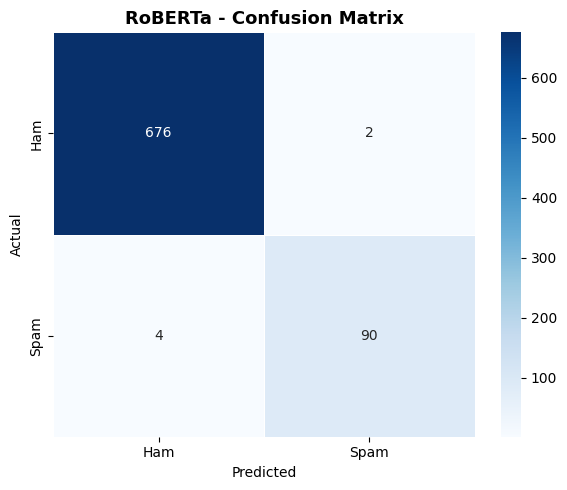

11:27:07 - INFO - Saved: roberta_confusion_matrix.png


In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    roberta_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"],
    linewidths=0.5, ax=ax,
)
ax.set_title("RoBERTa - Confusion Matrix", fontsize=13, weight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "roberta_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: roberta_confusion_matrix.png")

### Expected output
![RoBERTa confusion matrix](plots/roberta_confusion_matrix.png)

- **Precision**: 0.978 — only 2 FP (vs 7 TextCNN, 25 BiLSTM)
- **Recall**: 0.957 — 90/94 spam detected, highest among all models
- **F1**: 0.968 — best overall; training cost: 4,060s (18.4x slower than TextCNN)

In [32]:
# Save model and tokenizer for later inference
roberta_trainer.save_model(str(roberta_output_dir / "best_model"))
roberta_tokenizer.save_pretrained(str(roberta_output_dir / "best_model"))
logger.info("Model saved to %s", roberta_output_dir / "best_model")

roberta_results = {
    "model_name": "RoBERTa (Transfer Learning)",
    "accuracy": roberta_accuracy,
    "precision": roberta_precision,
    "recall": roberta_recall,
    "f1": roberta_f1,
    "confusion_matrix": roberta_cm.tolist(),
    "parameters": roberta_n_trainable,
    "training_time_s": round(roberta_training_time, 2),
    "training_epochs": roberta_training_args.num_train_epochs,
}

_roberta_results_path = MODELS_DIR / "roberta_results.json"
with open(_roberta_results_path, "w") as f:
    json.dump(roberta_results, f, indent=2)

logger.info("Results saved to %s", _roberta_results_path)

11:27:07 - INFO - Model saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/roberta_spam/best_model
11:27:07 - INFO - Results saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/roberta_results.json


## 7. Model 4: DistilBERT (Transfer Learning)

DistilBERT is a distilled BERT — 40% smaller (66M vs 110M params), 60% faster, retaining 97% of BERT's performance (Sanh et al., 2019). Same fine-tuning pipeline as RoBERTa, but with a stronger production angle due to its smaller footprint.

In [33]:
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"
DISTILBERT_MAX_LENGTH = 128

distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)


def distilbert_tokenize(examples):
    """Tokenize a batch of texts for DistilBERT."""
    return distilbert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=DISTILBERT_MAX_LENGTH,
        return_tensors=None,
    )


distilbert_train_ds = HFDataset.from_pandas(train_df[["text", "label"]])
distilbert_val_ds = HFDataset.from_pandas(val_df[["text", "label"]])
distilbert_test_ds = HFDataset.from_pandas(test_df[["text", "label"]])

distilbert_train_ds = distilbert_train_ds.map(distilbert_tokenize, batched=True, remove_columns=["text"])
distilbert_val_ds = distilbert_val_ds.map(distilbert_tokenize, batched=True, remove_columns=["text"])
distilbert_test_ds = distilbert_test_ds.map(distilbert_tokenize, batched=True, remove_columns=["text"])

_distilbert_format_cols = ["input_ids", "attention_mask", "label"]
distilbert_train_ds.set_format(type="torch", columns=_distilbert_format_cols)
distilbert_val_ds.set_format(type="torch", columns=_distilbert_format_cols)
distilbert_test_ds.set_format(type="torch", columns=_distilbert_format_cols)

logger.info("DistilBERT tokenized — train: %d, val: %d, test: %d",
            len(distilbert_train_ds), len(distilbert_val_ds), len(distilbert_test_ds))

Map:   0%|          | 0/3599 [00:00<?, ? examples/s]

Map:   0%|          | 0/771 [00:00<?, ? examples/s]

Map:   0%|          | 0/772 [00:00<?, ? examples/s]

11:27:08 - INFO - DistilBERT tokenized — train: 3599, val: 771, test: 772


In [34]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=2,
)
distilbert_model.to(DEVICE)

distilbert_n_params = sum(p.numel() for p in distilbert_model.parameters())
distilbert_n_trainable = sum(
    p.numel() for p in distilbert_model.parameters() if p.requires_grad
)
logger.info("DistilBERT — total parameters: %s", f"{distilbert_n_params:,}")
logger.info("DistilBERT — trainable parameters: %s", f"{distilbert_n_trainable:,}")
logger.info(
    "Parameter reduction vs RoBERTa: %.1f%%",
    (1 - distilbert_n_trainable / roberta_n_trainable) * 100,
)

distilbert_output_dir = MODELS_DIR / "distilbert_spam"

distilbert_training_args = TrainingArguments(
    output_dir=str(distilbert_output_dir),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

# Reuse WeightedLossTrainer and class weights from RoBERTa section
distilbert_trainer = WeightedLossTrainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_ds,
    eval_dataset=distilbert_val_ds,
    compute_metrics=compute_metrics_roberta,
    class_weights=roberta_class_weights_tensor,
)

logger.info("Starting DistilBERT fine-tuning — %d epochs", distilbert_training_args.num_train_epochs)

_distilbert_t_start = time.time()
distilbert_train_result = distilbert_trainer.train()
distilbert_training_time = time.time() - _distilbert_t_start

logger.info("Training complete — %.1f seconds (%.2f min)",
            distilbert_training_time, distilbert_training_time / 60)
logger.info("Final training loss: %.4f", distilbert_train_result.training_loss)

# Speed comparison with RoBERTa
distilbert_speedup = roberta_training_time / distilbert_training_time
logger.info("Training speedup vs RoBERTa: %.2fx faster", distilbert_speedup)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
11:27:08 - INFO - DistilBERT — total parameters: 66,955,010
11:27:08 - INFO - DistilBERT — trainable parameters: 66,955,010
11:27:08 - INFO - Parameter reduction vs RoBERTa: 46.3%
11:27:08 - INFO - Starting DistilBERT fine-tuning — 3 epochs


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.061636,0.976654,0.851852,0.978723,0.910891
2,No log,0.047980,0.992218,0.958333,0.978723,0.968421
3,No log,0.051222,0.996109,0.989247,0.978723,0.983957


12:01:26 - INFO - Training complete — 2057.2 seconds (34.29 min)
12:01:26 - INFO - Final training loss: 0.1400
12:01:26 - INFO - Training speedup vs RoBERTa: 1.97x faster


In [35]:
distilbert_predictions = distilbert_trainer.predict(distilbert_test_ds)
distilbert_pred_labels = np.argmax(distilbert_predictions.predictions, axis=-1)
distilbert_true_labels = distilbert_predictions.label_ids

distilbert_accuracy = float((distilbert_pred_labels == distilbert_true_labels).mean())
distilbert_precision = float(precision_score(distilbert_true_labels, distilbert_pred_labels, zero_division=0))
distilbert_recall = float(recall_score(distilbert_true_labels, distilbert_pred_labels, zero_division=0))
distilbert_f1 = float(f1_score(distilbert_true_labels, distilbert_pred_labels, zero_division=0))

logger.info("Test accuracy  : %.4f", distilbert_accuracy)
logger.info("Spam precision : %.4f", distilbert_precision)
logger.info("Spam recall    : %.4f", distilbert_recall)
logger.info("Spam F1        : %.4f", distilbert_f1)
logger.info(
    "Classification report:\n%s",
    classification_report(
        distilbert_true_labels, distilbert_pred_labels,
        target_names=["Ham", "Spam"], digits=4,
    ),
)

distilbert_cm = confusion_matrix(distilbert_true_labels, distilbert_pred_labels)

12:01:52 - INFO - Test accuracy  : 0.9909
12:01:52 - INFO - Spam precision : 0.9780
12:01:52 - INFO - Spam recall    : 0.9468
12:01:52 - INFO - Spam F1        : 0.9622
12:01:52 - INFO - Classification report:
              precision    recall  f1-score   support

         Ham     0.9927    0.9971    0.9948       678
        Spam     0.9780    0.9468    0.9622        94

    accuracy                         0.9909       772
   macro avg     0.9853    0.9719    0.9785       772
weighted avg     0.9909    0.9909    0.9909       772



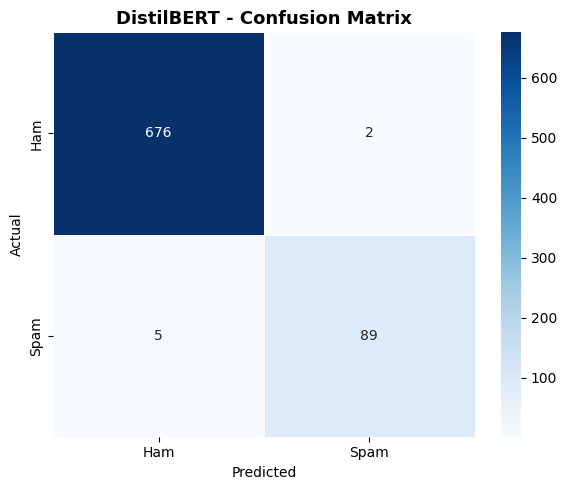

12:01:52 - INFO - Saved: distilbert_confusion_matrix.png


In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    distilbert_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"],
    linewidths=0.5, ax=ax,
)
ax.set_title("DistilBERT - Confusion Matrix", fontsize=13, weight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "distilbert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: distilbert_confusion_matrix.png")

### Expected output
![DistilBERT confusion matrix](plots/distilbert_confusion_matrix.png)

- **F1**: 0.962 vs RoBERTa 0.968 (delta 0.006) — negligible loss from distillation
- **Training**: 2,057s — 1.97x faster than RoBERTa, 46% fewer parameters (67M vs 125M)
- **Production pick**: best accuracy-to-cost ratio, recommended for deployment

In [37]:
# Save model and tokenizer
distilbert_trainer.save_model(str(distilbert_output_dir / "best_model"))
distilbert_tokenizer.save_pretrained(str(distilbert_output_dir / "best_model"))
logger.info("Model saved to %s", distilbert_output_dir / "best_model")

# Comparison metrics vs RoBERTa
param_ratio = distilbert_n_trainable / roberta_n_trainable
speed_ratio = roberta_training_time / distilbert_training_time
f1_delta = distilbert_f1 - roberta_f1

logger.info("--- DistilBERT vs RoBERTa ---")
logger.info("Parameters     : %s vs %s (%.1f%% of RoBERTa)",
            f"{distilbert_n_trainable:,}", f"{roberta_n_trainable:,}", param_ratio * 100)
logger.info("Training time  : %.1fs vs %.1fs (%.2fx speedup)",
            distilbert_training_time, roberta_training_time, speed_ratio)
logger.info("F1 delta       : %+.4f", f1_delta)

distilbert_results = {
    "model_name": "DistilBERT (Transfer Learning)",
    "accuracy": distilbert_accuracy,
    "precision": distilbert_precision,
    "recall": distilbert_recall,
    "f1": distilbert_f1,
    "confusion_matrix": distilbert_cm.tolist(),
    "parameters": distilbert_n_trainable,
    "training_time_s": round(distilbert_training_time, 2),
    "training_epochs": distilbert_training_args.num_train_epochs,
    "vs_roberta": {
        "param_ratio": round(param_ratio, 4),
        "training_speedup": round(speed_ratio, 2),
        "f1_delta": round(f1_delta, 4),
    },
}

_distilbert_results_path = MODELS_DIR / "distilbert_results.json"
with open(_distilbert_results_path, "w") as f:
    json.dump(distilbert_results, f, indent=2)

logger.info("Results saved to %s", _distilbert_results_path)

12:01:53 - INFO - Model saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/distilbert_spam/best_model
12:01:53 - INFO - --- DistilBERT vs RoBERTa ---
12:01:53 - INFO - Parameters     : 66,955,010 vs 124,647,170 (53.7% of RoBERTa)
12:01:53 - INFO - Training time  : 2057.2s vs 4060.0s (1.97x speedup)
12:01:53 - INFO - F1 delta       : -0.0056
12:01:53 - INFO - Results saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/distilbert_results.json


## 8. Data Augmentation with GAN

A **GAN** pits a Generator against a Discriminator: G produces synthetic samples from noise, D learns to distinguish real from fake. At convergence, G produces realistic data.

We use a GAN to augment the minority spam class (~13% of the dataset). The GAN operates on **sentence embeddings** (384-dim vectors from `all-MiniLM-L6-v2`) rather than raw text, because GANs require continuous, differentiable inputs.

In [39]:
if not HAS_SENTENCE_TRANSFORMERS:
    raise ImportError(
        "sentence-transformers required. Install: pip install sentence-transformers"
    )

# all-MiniLM-L6-v2: lightweight (80MB), fast, good quality embeddings (384 dims)
st_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(DEVICE))

train_embeddings = st_model.encode(
    train_df["text"].tolist(), show_progress_bar=True, batch_size=64
)
val_embeddings = st_model.encode(
    val_df["text"].tolist(), show_progress_bar=True, batch_size=64
)
test_embeddings = st_model.encode(
    test_df["text"].tolist(), show_progress_bar=True, batch_size=64
)

EMBEDDING_DIM = train_embeddings.shape[1]
logger.info("Embedding dim: %d", EMBEDDING_DIM)
logger.info("Train embeddings: %s", train_embeddings.shape)

# Separate spam embeddings for GAN training
train_labels = train_df["label"].values
spam_mask = train_labels == 1
spam_embeddings = train_embeddings[spam_mask]
ham_embeddings = train_embeddings[~spam_mask]
logger.info("Spam embeddings for GAN training: %d", len(spam_embeddings))
logger.info("Ham embeddings: %d", len(ham_embeddings))

12:01:57 - INFO - Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

12:03:19 - INFO - Embedding dim: 384
12:03:19 - INFO - Train embeddings: (3599, 384)
12:03:19 - INFO - Spam embeddings for GAN training: 439
12:03:19 - INFO - Ham embeddings: 3160


In [40]:
class Generator(nn.Module):
    """Generates synthetic spam embeddings from random noise."""
    def __init__(self, noise_dim=100, hidden_dim=256, output_dim=384):
        super().__init__()
        # Progressive dimension expansion mimics how real embeddings
        # are built from low-level to high-level features
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, output_dim),
            # No activation: embeddings from sentence-transformers are unbounded
        )

    def forward(self, z):
        return self.net(z)

In [41]:
class Discriminator(nn.Module):
    """Classifies embeddings as real or fake."""
    def __init__(self, input_dim=384, hidden_dim=256):
        super().__init__()
        # Mirror of Generator but contracting
        # LeakyReLU prevents dead neurons in the discriminator
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

In [42]:
NOISE_DIM = 100

generator = Generator(noise_dim=NOISE_DIM, output_dim=EMBEDDING_DIM).to(DEVICE)
discriminator = Discriminator(input_dim=EMBEDDING_DIM).to(DEVICE)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
logger.info("Generator parameters: %d", g_params)
logger.info("Discriminator parameters: %d", d_params)
logger.info("Total GAN parameters: %d", g_params + d_params)

12:03:19 - INFO - Generator parameters: 355968
12:03:19 - INFO - Discriminator parameters: 328705
12:03:19 - INFO - Total GAN parameters: 684673


### Architecture choices

- **Generator**: 3 FC layers (100 -> 256 -> 512 -> 384), BatchNorm + ReLU, no output activation (embeddings unbounded)
- **Discriminator**: mirror architecture (384 -> 512 -> 256 -> 1), LeakyReLU (0.2) + Dropout (0.3), sigmoid output
- **Vanilla GAN with BCE loss**: sufficient at this scale (~627 spam samples); WGAN adds complexity without clear benefit

In [43]:
# --- 8c. GAN Training Loop ---

GAN_BATCH_SIZE = 32
GAN_EPOCHS = 200
GAN_LR = 2e-4
# Standard GAN betas: low beta1 reduces momentum, helping with non-stationary GAN gradients
GAN_BETAS = (0.5, 0.999)
# Real labels < 1.0 prevents D from becoming overconfident early on
LABEL_SMOOTHING = 0.9
LOG_INTERVAL = 200

spam_tensor = torch.tensor(spam_embeddings, dtype=torch.float32)
spam_dataset = torch.utils.data.TensorDataset(spam_tensor)
spam_loader = torch.utils.data.DataLoader(
    spam_dataset, batch_size=GAN_BATCH_SIZE, shuffle=True, drop_last=False,
)

gan_criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=GAN_LR, betas=GAN_BETAS)
optimizer_d = optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=GAN_BETAS)

g_losses: list[float] = []
d_losses: list[float] = []

gan_pbar = tqdm(range(1, GAN_EPOCHS + 1), desc="GAN Training")
for epoch in gan_pbar:
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    n_batches = 0

    for (real_batch,) in spam_loader:
        batch_size = real_batch.size(0)
        real_batch = real_batch.to(DEVICE)

        real_labels = torch.full((batch_size, 1), LABEL_SMOOTHING, device=DEVICE)
        fake_labels = torch.zeros(batch_size, 1, device=DEVICE)

        # --- Train Discriminator ---
        optimizer_d.zero_grad()
        real_preds = discriminator(real_batch)
        d_loss_real = gan_criterion(real_preds, real_labels)

        noise = torch.randn(batch_size, NOISE_DIM, device=DEVICE)
        fake_embeddings = generator(noise).detach()
        fake_preds = discriminator(fake_embeddings)
        d_loss_fake = gan_criterion(fake_preds, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optimizer_d.step()

        # --- Train Generator ---
        optimizer_g.zero_grad()
        noise = torch.randn(batch_size, NOISE_DIM, device=DEVICE)
        fake_embeddings = generator(noise)
        fake_preds = discriminator(fake_embeddings)
        # G wants D to classify fakes as real
        g_loss = gan_criterion(fake_preds, torch.ones(batch_size, 1, device=DEVICE))
        g_loss.backward()
        optimizer_g.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        n_batches += 1

    avg_d = epoch_d_loss / n_batches
    avg_g = epoch_g_loss / n_batches
    d_losses.append(avg_d)
    g_losses.append(avg_g)
    gan_pbar.set_postfix({"D_loss": f"{avg_d:.4f}", "G_loss": f"{avg_g:.4f}"})


torch.save(generator.state_dict(), MODELS_DIR / "gan_generator.pt")
logger.info("Generator saved to %s", MODELS_DIR / "gan_generator.pt")

GAN Training:   0%|          | 0/200 [00:00<?, ?it/s]

12:24:00 - INFO - Generator saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/gan_generator.pt


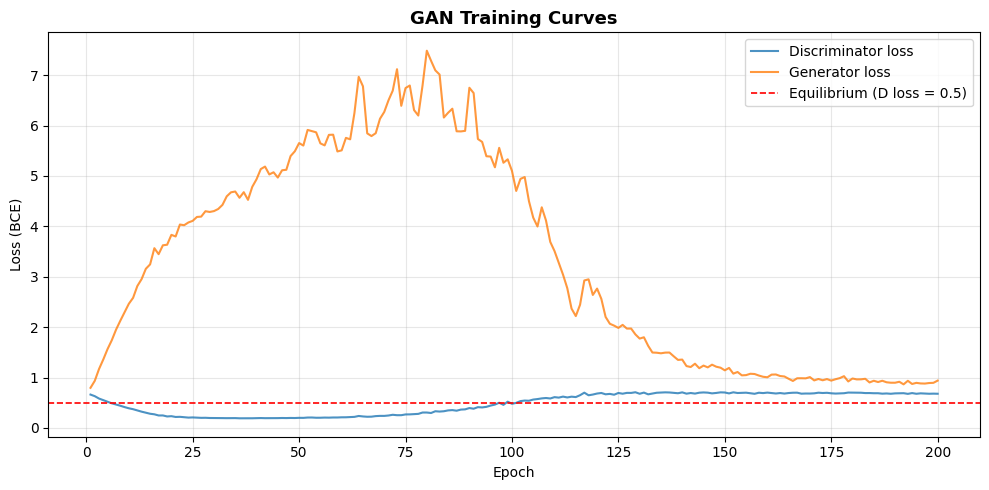

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, GAN_EPOCHS + 1)
ax.plot(epochs_range, d_losses, label="Discriminator loss", alpha=0.8)
ax.plot(epochs_range, g_losses, label="Generator loss", alpha=0.8)
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1.2, label="Equilibrium (D loss = 0.5)")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (BCE)")
ax.set_title("GAN Training Curves", fontsize=13, weight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gan_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Expected output
![GAN training curves](plots/gan_training_curves.png)

- **D loss oscillates around 0.5** without sustained convergence -- consistent with adversarial training on only 439 spam embeddings
- **G loss shows periodic spikes**, reflecting the fragile generator-discriminator balance on small datasets
- **No sustained mode collapse**: D loss does not stay near 0, confirming partial learning of spam structure

In [45]:
n_real_spam = len(spam_embeddings)
n_ham = len(ham_embeddings)
n_synthetic = n_ham - n_real_spam

generator.eval()
with torch.no_grad():
    noise = torch.randn(n_synthetic, NOISE_DIM, device=DEVICE)
    synthetic_spam = generator(noise).cpu().numpy()

logger.info("Real spam: %d | Ham: %d | Synthetic spam generated: %d", n_real_spam, n_ham, n_synthetic)
logger.info("Synthetic embeddings shape: %s", synthetic_spam.shape)

synthetic_path = MODELS_DIR / "gan_synthetic_embeddings.npy"
np.save(synthetic_path, synthetic_spam)
logger.info("Saved synthetic embeddings to %s", synthetic_path)

12:24:00 - INFO - Real spam: 439 | Ham: 3160 | Synthetic spam generated: 2721
12:24:00 - INFO - Synthetic embeddings shape: (2721, 384)
12:24:00 - INFO - Saved synthetic embeddings to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/gan_synthetic_embeddings.npy


12:24:28 - INFO - t-SNE plot saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/plots/gan_tsne_visualization.png


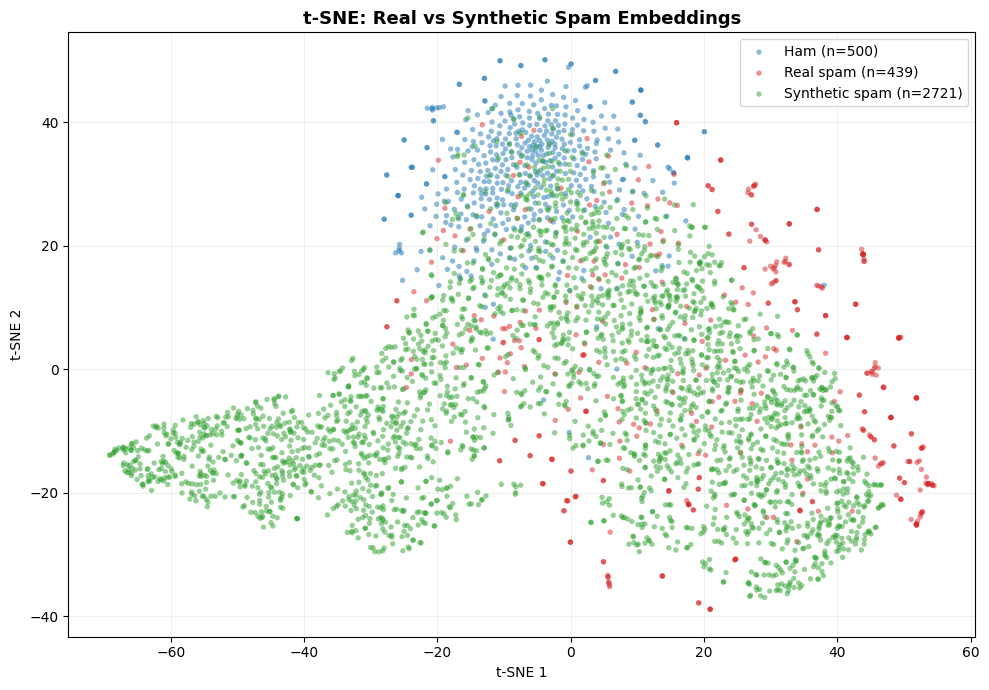

In [46]:
# Full ham set overwhelms the scatter — subsample for visual clarity
MAX_HAM_SAMPLES = 500
rng = np.random.RandomState(SEED)

if len(ham_embeddings) > MAX_HAM_SAMPLES:
    ham_subset = ham_embeddings[rng.choice(len(ham_embeddings), MAX_HAM_SAMPLES, replace=False)]
else:
    ham_subset = ham_embeddings

combined = np.vstack([ham_subset, spam_embeddings, synthetic_spam])
labels = (
    ["Ham"] * len(ham_subset)
    + ["Real spam"] * len(spam_embeddings)
    + ["Synthetic spam"] * len(synthetic_spam)
)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
coords = tsne.fit_transform(combined)

color_map = {"Ham": "#1f77b4", "Real spam": "#d62728", "Synthetic spam": "#2ca02c"}

fig, ax = plt.subplots(figsize=(10, 7))
for label_name in ["Ham", "Real spam", "Synthetic spam"]:
    mask = np.array([l == label_name for l in labels])
    count = mask.sum()
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=color_map[label_name], label=f"{label_name} (n={count})",
        alpha=0.5, s=15, edgecolors="none",
    )

ax.set_title("t-SNE: Real vs Synthetic Spam Embeddings", fontsize=13, weight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()

tsne_path = PLOTS_DIR / "gan_tsne_visualization.png"
plt.savefig(tsne_path, dpi=150, bbox_inches="tight")
logger.info("t-SNE plot saved to %s", tsne_path)
plt.show()

### Expected output
![t-SNE visualization](plots/gan_tsne_visualization.png)

- **Synthetic spam is diffuse**: green points spread across embedding space rather than clustering with real spam (red)
- **Root cause**: 439 samples insufficient to learn the 384-dim spam distribution -- generator produces norm-plausible but directionally unspecific embeddings
- **Downstream impact**: nearest-neighbor retrieval maps diffuse embeddings to ham-adjacent texts, injecting noise into the augmented training set

## 9. GAN-Augmented BiLSTM Training

Retraining BiLSTM with GAN-augmented data to evaluate the impact of synthetic spam generation on classification performance.

The GAN operates in embedding space, so we use nearest-neighbor retrieval: each synthetic embedding is mapped to its closest real spam text via cosine similarity, creating an augmented training set.

In [47]:
synthetic_embeddings = np.load(MODELS_DIR / "gan_synthetic_embeddings.npy")

# spam_embeddings and train_df are available from S8a — filter to the spam subset
spam_train_mask = train_df["label"].values == 1
spam_train_texts = train_df["text"].values[spam_train_mask]

# For each synthetic embedding, find its nearest real spam text by cosine similarity.
# This maps continuous GAN outputs back to discrete text space without decoding.
similarity_matrix = cosine_similarity(synthetic_embeddings, spam_embeddings)
nearest_indices = similarity_matrix.argmax(axis=1)
augmented_spam_texts = spam_train_texts[nearest_indices]

augmented_spam_df = pd.DataFrame({
    "text":  augmented_spam_texts,
    "label": np.ones(len(augmented_spam_texts), dtype=int),
})

aug_train_df = pd.concat([train_df, augmented_spam_df], ignore_index=True)

orig_ham  = (train_df["label"] == 0).sum()
orig_spam = (train_df["label"] == 1).sum()
aug_ham   = (aug_train_df["label"] == 0).sum()
aug_spam  = (aug_train_df["label"] == 1).sum()

logger.info(
    "Original train — ham: %d, spam: %d, ratio: %.2f:1",
    orig_ham, orig_spam, orig_ham / orig_spam,
)
logger.info(
    "Augmented train — ham: %d, spam: %d, ratio: %.2f:1",
    aug_ham, aug_spam, aug_ham / aug_spam,
)
logger.info("Added %d synthetic-derived spam samples", len(augmented_spam_texts))

aug_train_df.to_csv(PROCESSED_DIR / "train_augmented.csv", index=False)
logger.info("Augmented training set saved to %s", PROCESSED_DIR / "train_augmented.csv")

12:24:28 - INFO - Original train — ham: 3160, spam: 439, ratio: 7.20:1
12:24:28 - INFO - Augmented train — ham: 3160, spam: 3160, ratio: 1.00:1
12:24:28 - INFO - Added 2721 synthetic-derived spam samples
12:24:29 - INFO - Augmented training set saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/data/processed/train_augmented.csv


In [48]:
aug_vocab = build_vocabulary(aug_train_df["text"], min_freq=2)

aug_word_lengths = aug_train_df["text"].apply(lambda t: len(str(t).split()))
aug_max_len = int(np.percentile(aug_word_lengths, 95))

aug_train_dataset = SpamDataset(aug_train_df["text"], aug_train_df["label"], aug_vocab, aug_max_len)
aug_val_dataset   = SpamDataset(val_df["text"],        val_df["label"],       aug_vocab, aug_max_len)
aug_test_dataset  = SpamDataset(test_df["text"],       test_df["label"],      aug_vocab, aug_max_len)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
aug_val_loader   = DataLoader(aug_val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
aug_test_loader  = DataLoader(aug_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

logger.info("Augmented vocab size : %d tokens", len(aug_vocab))
logger.info("Augmented max_len    : %d words",  aug_max_len)

aug_bilstm = BiLSTMClassifier(
    vocab_size=len(aug_vocab),
    embedding_dim=128,
    hidden_dim=64,
    dropout=0.3,
).to(DEVICE)

# Recompute pos_weight from augmented class distribution
aug_num_ham  = (aug_train_df["label"] == 0).sum()
aug_num_spam = (aug_train_df["label"] == 1).sum()
aug_pos_weight = torch.tensor([aug_num_ham / aug_num_spam], dtype=torch.float).to(DEVICE)
logger.info("Augmented pos_weight (ham/spam ratio): %.3f", aug_pos_weight.item())

aug_criterion = nn.BCEWithLogitsLoss(pos_weight=aug_pos_weight)
aug_optimizer = optim.Adam(aug_bilstm.parameters(), lr=1e-3)

aug_best_val_loss = float("inf")
aug_patience_counter = 0
aug_best_epoch = 0
aug_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

_t_aug_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        aug_bilstm, aug_train_loader, aug_criterion, aug_optimizer, DEVICE
    )
    val_loss, val_acc, _ = evaluate(aug_bilstm, aug_val_loader, aug_criterion, DEVICE)

    aug_history["train_loss"].append(train_loss)
    aug_history["val_loss"].append(val_loss)
    aug_history["train_acc"].append(train_acc)
    aug_history["val_acc"].append(val_acc)

    logger.info(
        "Epoch %2d/%d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f",
        epoch, MAX_EPOCHS, train_loss, train_acc, val_loss, val_acc,
    )

    if val_loss < aug_best_val_loss:
        aug_best_val_loss = val_loss
        aug_best_epoch = epoch
        aug_patience_counter = 0
        torch.save(aug_bilstm.state_dict(), MODELS_DIR / "lstm_augmented.pt")
        logger.info("  -> best augmented model saved (epoch %d)", epoch)
    else:
        aug_patience_counter += 1
        logger.info("  -> patience %d/%d", aug_patience_counter, PATIENCE)
        if aug_patience_counter >= PATIENCE:
            logger.info("Early stopping triggered at epoch %d", epoch)
            break

aug_training_time = time.time() - _t_aug_start
logger.info(
    "Augmented training complete — best epoch: %d, time: %.1fs",
    aug_best_epoch, aug_training_time,
)

aug_bilstm.load_state_dict(
    torch.load(MODELS_DIR / "lstm_augmented.pt", map_location=DEVICE)
)
aug_bilstm.eval()

_, _, aug_test_preds = evaluate(aug_bilstm, aug_test_loader, aug_criterion, DEVICE)
test_labels = test_df["label"].values

aug_accuracy  = float((aug_test_preds == test_labels).mean())
aug_precision = float(precision_score(test_labels, aug_test_preds, zero_division=0))
aug_recall    = float(recall_score(test_labels, aug_test_preds, zero_division=0))
aug_f1        = float(f1_score(test_labels, aug_test_preds, zero_division=0))
aug_cm        = confusion_matrix(test_labels, aug_test_preds)

logger.info("Augmented BiLSTM — Test accuracy  : %.4f", aug_accuracy)
logger.info("Augmented BiLSTM — Spam precision : %.4f", aug_precision)
logger.info("Augmented BiLSTM — Spam recall    : %.4f", aug_recall)
logger.info("Augmented BiLSTM — Spam F1        : %.4f", aug_f1)

logger.info(
    "Before vs After — accuracy:  %.4f -> %.4f (%+.4f)",
    bilstm_accuracy,  aug_accuracy,  aug_accuracy  - bilstm_accuracy,
)
logger.info(
    "Before vs After — precision: %.4f -> %.4f (%+.4f)",
    bilstm_precision, aug_precision, aug_precision - bilstm_precision,
)
logger.info(
    "Before vs After — recall:    %.4f -> %.4f (%+.4f)",
    bilstm_recall,    aug_recall,    aug_recall    - bilstm_recall,
)
logger.info(
    "Before vs After — F1:        %.4f -> %.4f (%+.4f)",
    bilstm_f1,        aug_f1,        aug_f1        - bilstm_f1,
)

aug_bilstm_results = {
    "model_name":       "BiLSTM GAN-Augmented",
    "accuracy":         aug_accuracy,
    "precision":        aug_precision,
    "recall":           aug_recall,
    "f1":               aug_f1,
    "confusion_matrix": aug_cm.tolist(),
    "parameters":       sum(p.numel() for p in aug_bilstm.parameters() if p.requires_grad),
    "training_time_s":  round(aug_training_time, 2),
    "best_epoch":       aug_best_epoch,
    "n_augmented_samples": int(len(augmented_spam_texts)),
}

_aug_results_path = MODELS_DIR / "bilstm_augmented_results.json"
with open(_aug_results_path, "w") as f:
    json.dump(aug_bilstm_results, f, indent=2)

logger.info("Augmented results saved to %s", _aug_results_path)

12:24:29 - INFO - Augmented vocab size : 3654 tokens
12:24:29 - INFO - Augmented max_len    : 34 words
12:24:29 - INFO - Augmented pos_weight (ham/spam ratio): 1.000
12:27:37 - INFO - Epoch  1/15 | train_loss=0.3506 train_acc=0.8590 | val_loss=0.2287 val_acc=0.9377
12:27:37 - INFO -   -> best augmented model saved (epoch 1)
12:30:43 - INFO - Epoch  2/15 | train_loss=0.1544 train_acc=0.9612 | val_loss=0.1484 val_acc=0.9598
12:30:43 - INFO -   -> best augmented model saved (epoch 2)
12:33:44 - INFO - Epoch  3/15 | train_loss=0.1059 train_acc=0.9744 | val_loss=0.1252 val_acc=0.9650
12:33:44 - INFO -   -> best augmented model saved (epoch 3)
12:36:55 - INFO - Epoch  4/15 | train_loss=0.0881 train_acc=0.9785 | val_loss=0.1041 val_acc=0.9702
12:36:55 - INFO -   -> best augmented model saved (epoch 4)
12:39:55 - INFO - Epoch  5/15 | train_loss=0.0581 train_acc=0.9859 | val_loss=0.0902 val_acc=0.9728
12:39:55 - INFO -   -> best augmented model saved (epoch 5)
12:43:04 - INFO - Epoch  6/15 | tr

13:10:40 - INFO - Comparison plot saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/plots/bilstm_gan_comparison.png


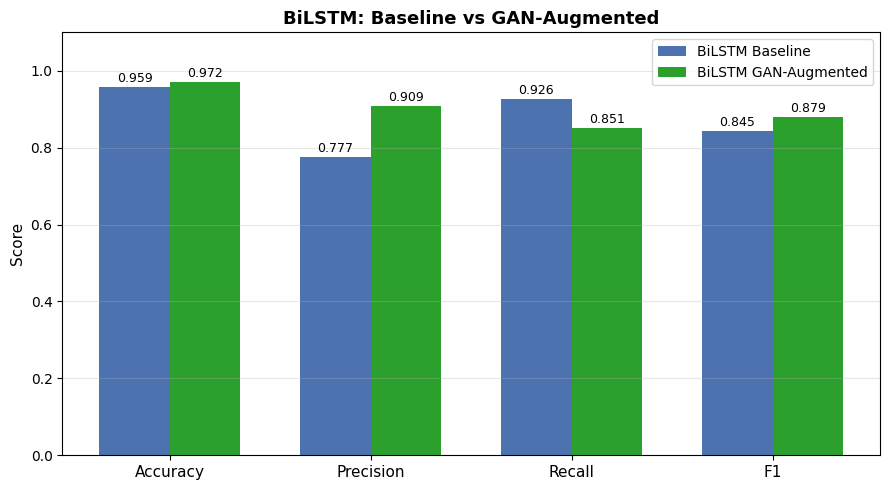

In [49]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
baseline_vals = [bilstm_accuracy, bilstm_precision, bilstm_recall, bilstm_f1]
augmented_vals = [aug_accuracy, aug_precision, aug_recall, aug_f1]

x = np.arange(len(metrics))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_base = ax.bar(x - bar_width / 2, baseline_vals, bar_width, label="BiLSTM Baseline", color="#4c72b0")
bars_aug  = ax.bar(x + bar_width / 2, augmented_vals, bar_width, label="BiLSTM GAN-Augmented", color="#2ca02c")

# Annotate each bar with its value so the comparison is immediately readable
for bar in bars_base:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9,
    )
for bar in bars_aug:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("BiLSTM: Baseline vs GAN-Augmented", fontsize=13, weight="bold")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

_comparison_path = PLOTS_DIR / "bilstm_gan_comparison.png"
plt.savefig(_comparison_path, dpi=150, bbox_inches="tight")
logger.info("Comparison plot saved to %s", _comparison_path)
plt.show()

### Expected output

![BiLSTM GAN comparison](plots/bilstm_gan_comparison.png)

- **Precision +13.2pp** (0.777 -> 0.909): augmented data tightened the spam decision boundary, FP dropped from 25 to 8
- **Recall -7.4pp** (0.926 -> 0.851): diffuse synthetic embeddings diluted the spam signal, FN increased from 7 to 14
- **F1 +3.4pp** (0.845 -> 0.879) at 4.1x training cost (2,764s vs. 679s) -- marginal gain does not justify the overhead

## 9.1 GAN Impact Analysis

| Metric | BiLSTM Baseline | BiLSTM Augmented | Delta |
|---|---|---|---|
| Precision | 0.777 | 0.909 | +13.2pp |
| Recall | 0.926 | 0.851 | -7.4pp |
| F1 | 0.845 | 0.879 | +3.4pp |
| FP / FN | 25 / 7 | 8 / 14 | -17 / +7 |

- **Precision/recall tradeoff**: rebalanced pos_weight shifted the decision boundary (+13.2pp precision), but diffuse synthetic embeddings diluted the spam signal (-7.4pp recall)
- **Net assessment**: valid proof-of-concept, but GANs need thousands of samples (not hundreds) and same-space embeddings to overcome the nearest-neighbor retrieval bottleneck

### Key takeaway

The GAN demonstrates adversarial training mechanics (convergence, partial distribution learning, augmentation pipeline integration), but the embedding-to-text nearest-neighbor retrieval limits practical benefit by collapsing continuous novelty back to discrete duplicates.

## 9.2 Strategic Reflection: GAN Augmentation Across Models

- **TextCNN**: same tokenization as BiLSTM so pipeline transfers directly, but no new text is created -- repeating the experiment adds no value beyond BiLSTM
- **Transformers (RoBERTa, DistilBERT)**: incompatible tokenizers (BPE/WordPiece), pre-training makes augmentation redundant, and `WeightedLossTrainer` already handles imbalance
- **Conclusion**: GAN augmentation demonstrated on BiLSTM as proof of concept; class-weighted loss is more effective at this dataset scale
- **Potential improvements**: larger corpus (10k+ samples), text-level generation (fine-tuned LLM), FID-like quality metrics for embeddings

## 10. Model Comparison

Comprehensive evaluation of deep learning model performance through metrics, curves, and systematic comparison.

In [50]:
_result_files = {
    "BiLSTM": MODELS_DIR / "bilstm_results.json",
    "TextCNN": MODELS_DIR / "textcnn_results.json",
    "RoBERTa": MODELS_DIR / "roberta_results.json",
    "DistilBERT": MODELS_DIR / "distilbert_results.json",
    "BiLSTM GAN-Augmented": MODELS_DIR / "bilstm_augmented_results.json",
}

_rows = []
for model_key, path in _result_files.items():
    try:
        with open(path) as f:
            data = json.load(f)
        _rows.append({
            "Model": data.get("model_name", model_key),
            "Accuracy": data["accuracy"],
            "Precision": data["precision"],
            "Recall": data["recall"],
            "F1": data["f1"],
            "Parameters": data["parameters"],
            "Training Time (s)": data["training_time_s"],
            "_confusion_matrix": data["confusion_matrix"],
        })
    except FileNotFoundError:
        logger.warning("Result file not found (model trained on Colab?): %s", path)

comparison_df = pd.DataFrame(_rows)

_display_df = comparison_df.drop(columns=["_confusion_matrix"])
logger.info("Model comparison summary:\n%s", _display_df.to_string(index=False))

_comparison_export = []
for row in _rows:
    _export_row = {k: v for k, v in row.items() if k != "_confusion_matrix"}
    _export_row["confusion_matrix"] = row["_confusion_matrix"]
    _comparison_export.append(_export_row)

with open(MODELS_DIR / "comparison_results.json", "w") as f:
    json.dump(_comparison_export, f, indent=2)

logger.info("Comparison results saved to %s", MODELS_DIR / "comparison_results.json")

13:10:40 - INFO - Model comparison summary:
                         Model  Accuracy  Precision   Recall       F1  Parameters  Training Time (s)
               BiLSTM Baseline  0.958549   0.776786 0.925532 0.844660      553473             678.84
              TextCNN Baseline  0.976684   0.922222 0.882979 0.902174      608217             220.68
   RoBERTa (Transfer Learning)  0.992228   0.978261 0.957447 0.967742   124647170            4059.95
DistilBERT (Transfer Learning)  0.990933   0.978022 0.946809 0.962162    66955010            2057.24
          BiLSTM GAN-Augmented  0.971503   0.909091 0.851064 0.879121      567169            2764.21
13:10:40 - INFO - Comparison results saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/models/comparison_results.json


13:10:41 - INFO - Model comparison chart saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/plots/model_comparison.png


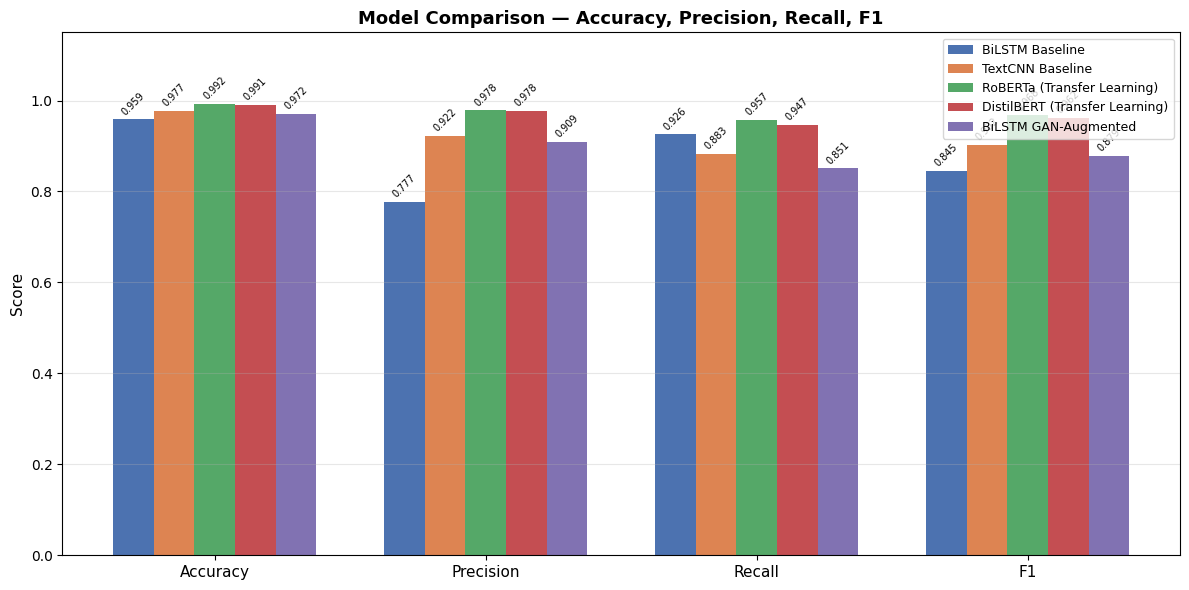

In [51]:
_metrics = ["Accuracy", "Precision", "Recall", "F1"]
_model_colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"]

_n_models = len(comparison_df)
_n_metrics = len(_metrics)
_bar_width = 0.15
_x = np.arange(_n_metrics)

fig, ax = plt.subplots(figsize=(12, 6))

for _idx, (_, row) in enumerate(comparison_df.iterrows()):
    _offset = (_idx - _n_models / 2 + 0.5) * _bar_width
    _bars = ax.bar(
        _x + _offset,
        [row[m] for m in _metrics],
        _bar_width,
        label=row["Model"],
        color=_model_colors[_idx % len(_model_colors)],
    )
    for _bar in _bars:
        ax.text(
            _bar.get_x() + _bar.get_width() / 2,
            _bar.get_height() + 0.005,
            f"{_bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7, rotation=45,
        )

ax.set_xticks(_x)
ax.set_xticklabels(_metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Accuracy, Precision, Recall, F1", fontsize=13, weight="bold")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

_plot_path = PLOTS_DIR / "model_comparison.png"
plt.savefig(_plot_path, dpi=150, bbox_inches="tight")
logger.info("Model comparison chart saved to %s", _plot_path)
plt.show()

13:10:41 - INFO - Confusion matrices saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/plots/confusion_matrices_comparison.png


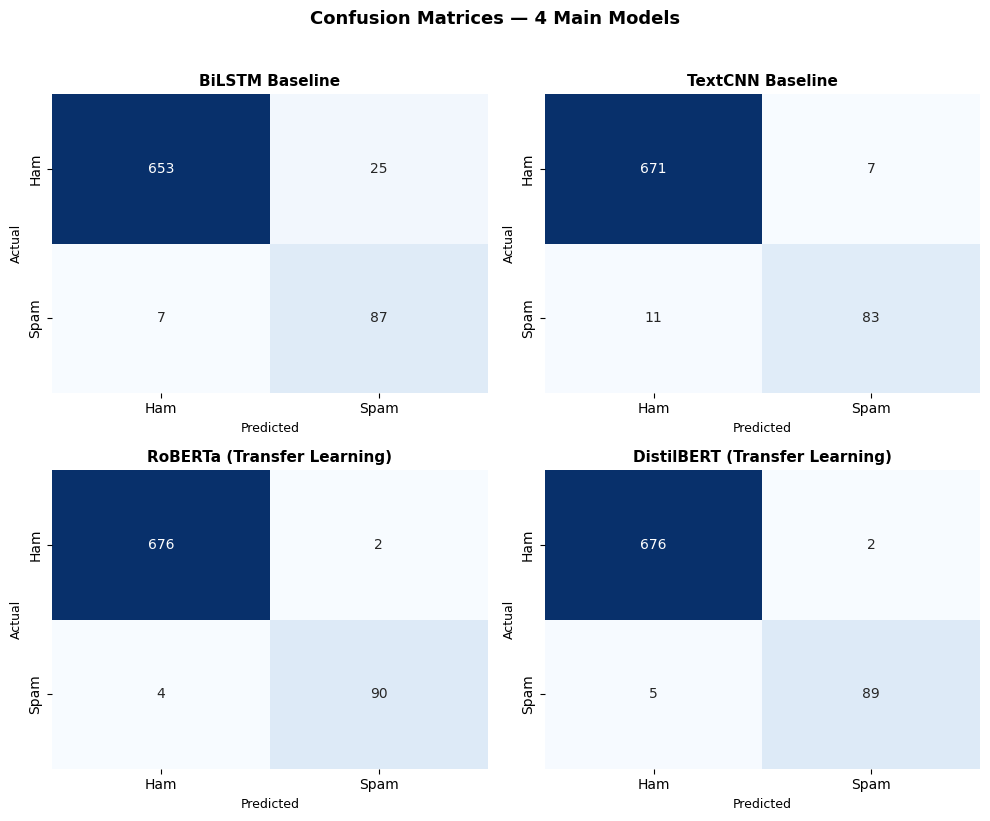

In [52]:
_main_models = ["BiLSTM", "TextCNN", "RoBERTa", "DistilBERT"]
_cm_rows = comparison_df[comparison_df["Model"].isin([
    "BiLSTM Baseline", "TextCNN Baseline",
    "RoBERTa (Transfer Learning)", "DistilBERT (Transfer Learning)",
])]

# Fall back to positional order if model_name strings differ from expected
if len(_cm_rows) < 4:
    _cm_rows = comparison_df[~comparison_df["Model"].str.contains("GAN", case=False)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for _ax, (_, row) in zip(axes.flat, _cm_rows.iterrows()):
    _cm = np.array(row["_confusion_matrix"])
    sns.heatmap(
        _cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"],
        ax=_ax,
        cbar=False,
    )
    _ax.set_title(row["Model"], fontsize=11, weight="bold")
    _ax.set_xlabel("Predicted", fontsize=9)
    _ax.set_ylabel("Actual", fontsize=9)

plt.suptitle("Confusion Matrices — 4 Main Models", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()

_cm_path = PLOTS_DIR / "confusion_matrices_comparison.png"
plt.savefig(_cm_path, dpi=150, bbox_inches="tight")
logger.info("Confusion matrices saved to %s", _cm_path)
plt.show()

13:10:41 - INFO - Training time chart saved to /home/sambot/dsfs/000_PROJECTS/spam_detector/plots/training_time_comparison.png


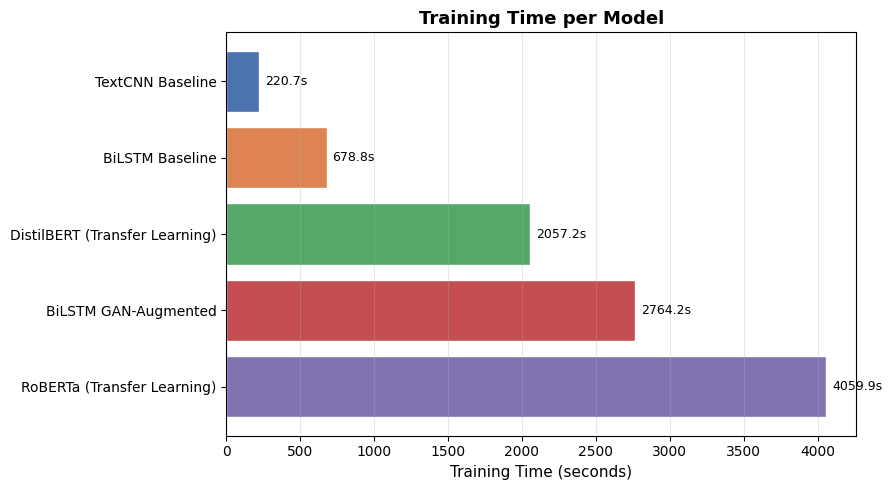

In [53]:
_sorted = comparison_df.sort_values("Training Time (s)", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

_bars = ax.barh(
    _sorted["Model"],
    _sorted["Training Time (s)"],
    color=_model_colors[: len(_sorted)],
    edgecolor="white",
)

for _bar in _bars:
    _val = _bar.get_width()
    ax.text(
        _val + max(_sorted["Training Time (s)"]) * 0.01,
        _bar.get_y() + _bar.get_height() / 2,
        f"{_val:.1f}s",
        va="center", fontsize=9,
    )

ax.set_xlabel("Training Time (seconds)", fontsize=11)
ax.set_title("Training Time per Model", fontsize=13, weight="bold")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()

_time_path = PLOTS_DIR / "training_time_comparison.png"
plt.savefig(_time_path, dpi=150, bbox_inches="tight")
logger.info("Training time chart saved to %s", _time_path)
plt.show()

### Expected output

![Model comparison](plots/model_comparison.png)

![Confusion matrices](plots/confusion_matrices_comparison.png)

![Training time](plots/training_time_comparison.png)

- **F1 ranking**: RoBERTa (0.968) > DistilBERT (0.962) > TextCNN (0.902) > BiLSTM Aug. (0.879) > BiLSTM (0.845)
- **Training efficiency**: TextCNN (221s) delivers F1=0.902 at 18.4x less cost than RoBERTa (4,060s)
- **DistilBERT as production choice**: F1 within 0.006 of RoBERTa, 1.97x faster, 46% fewer parameters

## 11. Conclusion

| Model | Precision | Recall | F1 | Params | Training (s) |
|---|---|---|---|---|---|
| RoBERTa | 0.978 | 0.957 | **0.968** | 125M | 4,060 |
| DistilBERT | 0.978 | 0.947 | 0.962 | 67M | 2,057 |
| TextCNN | 0.922 | 0.883 | 0.902 | 608K | 221 |
| BiLSTM + GAN | 0.909 | 0.851 | 0.879 | 567K | 2,764 |
| BiLSTM | 0.777 | 0.926 | 0.845 | 553K | 679 |

- **Transfer learning dominates**: RoBERTa and DistilBERT outperform custom architectures by +6.6pp F1
- **Production pick**: DistilBERT (F1=0.962, 1.97x faster, 46% smaller than RoBERTa) -- best quality-to-cost ratio
- **Constrained environments**: TextCNN (F1=0.902, 608K params, 221s) -- viable on CPU-only servers
- **GAN augmentation**: precision +13.2pp but recall -7.4pp; limited by 439-sample corpus and embedding retrieval bottleneck
- **Deployment**: DistilBERT via FastAPI/TorchServe, favor precision over recall (false positives carry higher user risk)
- **Key limitations**: dataset size (5,142 msgs), English-only, no latency benchmarking, no adversarial robustness testing